# Block modelling inversion with CSI

In this notebook, we show an example on how to build block models in CSI.
The implementation of block modelling in CSI is based on the framework of [Meade and Loveless, 2009](https://doi.org/10.1785/0120090088).
We also show how to use block modelling to estimate interseismic coupling along a fault.
This is a simple example using homogeneous elastic half space and no refined elastic structures.
More advanced things can be done, including building the input files for external solvers, adding other deformations, computing stratified Green's functions ...
The InSAR data have already been downsampled and the GNSS data are already curated.

## Python imports

In [1]:
# Imports
import cmcrameri.cm as cmc
import numpy as np
import scipy.stats as scistats

# Import csi
import csi

# F*** off warnings
import warnings
warnings.simplefilter("ignore") 

# Some styling changes
from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

## General setting

We set the reference point for the custom UTM zone.

In [2]:
lon0 = 39.
lat0 = 39.

## Setup Deformation Sources

In this section, we will first create blocks and faults using ready-made geometries. Blocks and faults are the basic components of a block model in csi (MultiBlock object).

### Setup Blocks

We start by defining the main tectonic blocks in the region, they are defined solely by their boundaries.

#### *Arabia*

---------------------------------
---------------------------------
Initializing block Arabia


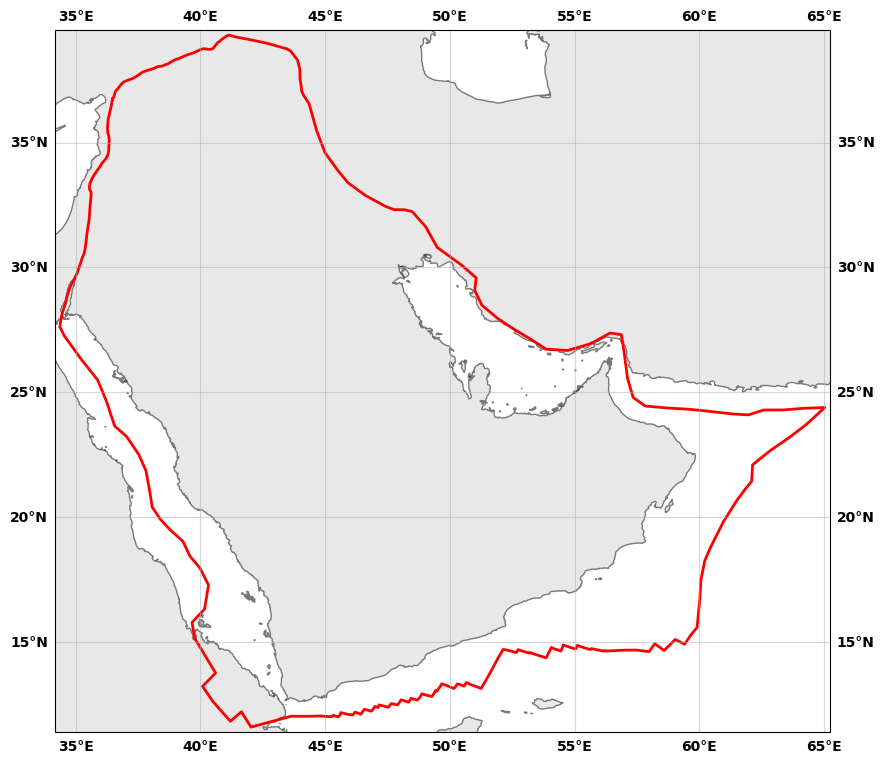

In [3]:
# Initialize the csi block object
block_arabia = csi.Block(name='Arabia', lon0=lon0, lat0=lat0)

# Read the block boundary from file
block_arabia.file2boundary("DataAndModels/tutoBlockModel/block_arabia.txt")

# Compute the reference point (centroid of the block, only for intrablock deformation)
block_arabia.setRefPoint()

# Plot parameters
block_arabia.color = 'r'
block_arabia.linewidth = 2

# Plot
block_arabia.plot()

#### *Eurasia*

---------------------------------
---------------------------------
Initializing block Eurasia


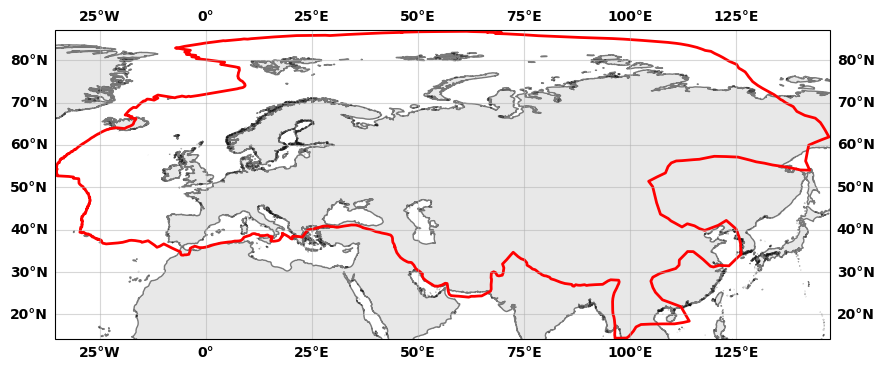

In [4]:
# Initialize the csi block object
block_eurasia = csi.Block(name='Eurasia', lon0=lon0, lat0=lat0)

# Read the block boundary from file
block_eurasia.file2boundary("DataAndModels/tutoBlockModel/block_eurasia.txt")

# Compute the reference point (centroid of the block, only for intrablock deformation)
block_eurasia.setRefPoint()

# Plot parameters
block_eurasia.color = 'r'
block_eurasia.linewidth = 2

# Plot
block_eurasia.plot()

#### *Africa*

---------------------------------
---------------------------------
Initializing block Nubia


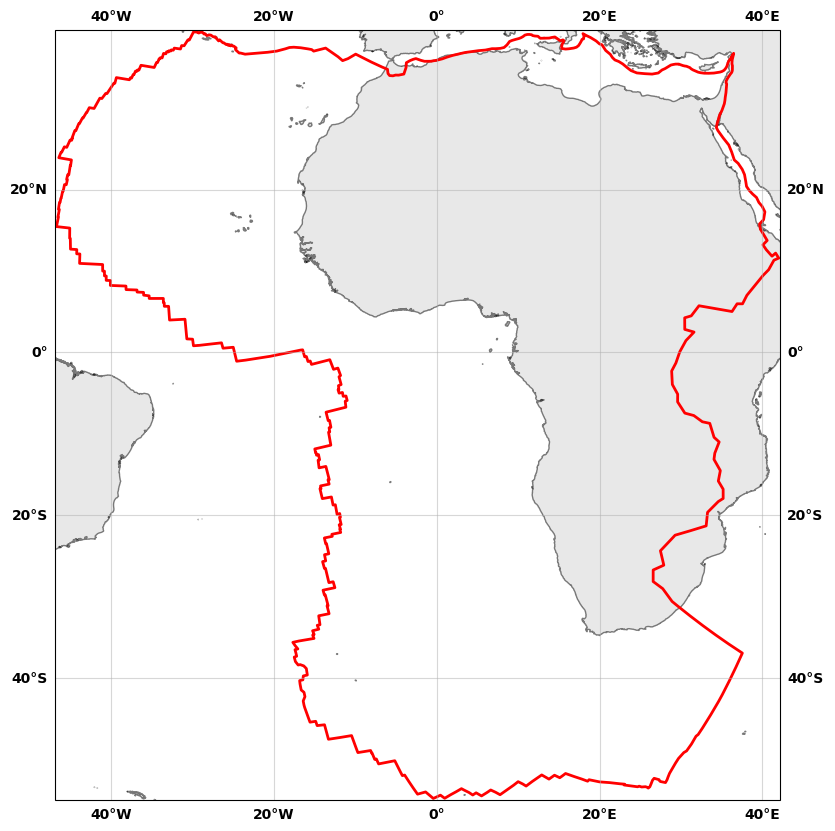

In [5]:
# Initialize the csi block object
block_africa = csi.Block(name='Nubia', lon0=lon0, lat0=lat0)

# Read the block boundary from file
block_africa.file2boundary("DataAndModels/tutoBlockModel/block_africa.txt")

# Compute the reference point (centroid of the block, only for intrablock deformation)
block_africa.setRefPoint()

# Plot parameters
block_africa.color = 'r'
block_africa.linewidth = 2

# Plot
block_africa.plot()

#### *Anatolia*

---------------------------------
---------------------------------
Initializing block Anatolia


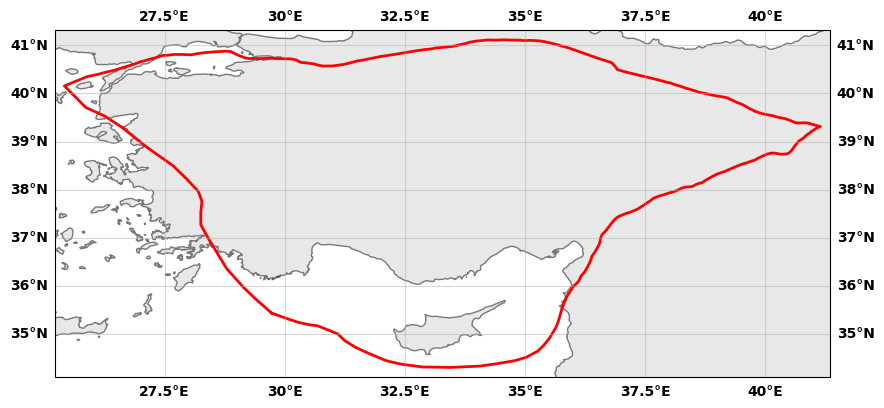

In [6]:
# Initialize the csi block object
block_anatolia = csi.Block(name='Anatolia', lon0=lon0, lat0=lat0)

# Read the block boundary from file
block_anatolia.file2boundary("DataAndModels/tutoBlockModel/block_anatolia.txt")

# Compute the reference point (centroid of the block, only for intrablock deformation)
block_anatolia.setRefPoint()

# Plot parameters
block_anatolia.color = 'r'
block_anatolia.linewidth = 2

# Plot
block_anatolia.plot()

#### *Concatenate blocks*

In [7]:
Blocks = [block_arabia, block_eurasia, block_africa, block_anatolia]

### Setup Faults

Next, we define the faults that form block boundaries and for which we wish to account for elastic deformation. It is strongly recommended that you use the same trace for block boundaries and fault traces.

#### *East Anatolian Fault*

---------------------------------
---------------------------------
Initializing fault EAF


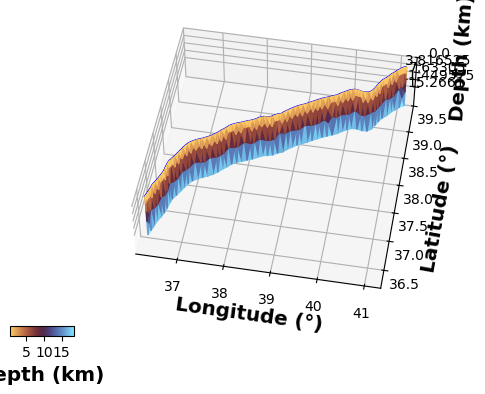

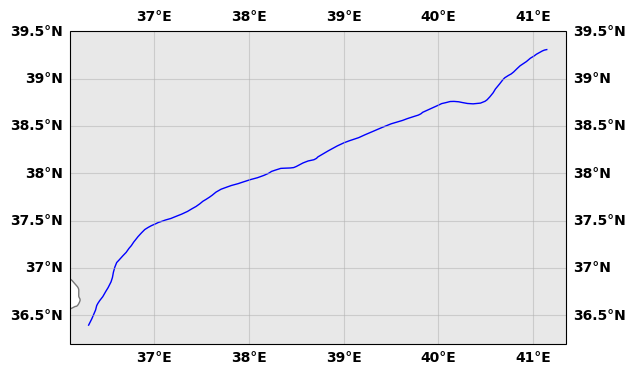

In [8]:
# Initialize the csi fault object
fault_EAF = csi.TriangularPatches('EAF', lon0=lon0, lat0=lat0)

# Read the fault trace and mesh from file
fault_EAF.file2trace("DataAndModels/tutoBlockModel/fault_EAF_trace.txt", header=0)
fault_EAF.readPatchesFromFile("DataAndModels/tutoBlockModel/fault_EAF_mesh.txt", readpatchindex=False, donotreadslip=True)

# Discetize the trace
fault_EAF.discretize(every=1.)

# We force all triangles to be considered vertical
fault_EAF.vertical = True

# Homogeneize the strike of the fault patches
fault_EAF.homogeneizeStrike(direction=0)

# Initialize the slip values on the fault patches
fault_EAF.initializeslip(values='depth')

# Plot parameters
fault_EAF.color = 'b'

# Plot
fault_EAF.plot(slip='strikeslip', cmap=cmc.managua, cblabel='depth (km)',
               view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4], plot_on_2d=False)

#### *North Anatolian Fault*

---------------------------------
---------------------------------
Initializing fault NAF


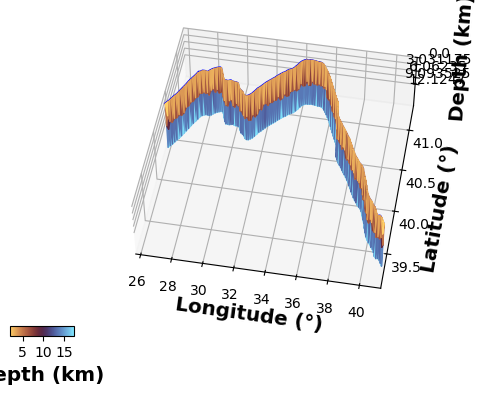

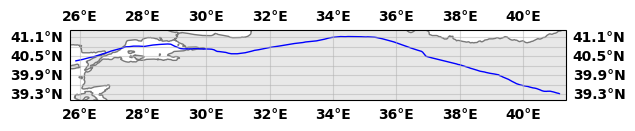

In [9]:
# Initialize the csi fault object
fault_NAF = csi.TriangularPatches('NAF', lon0=lon0, lat0=lat0)

# Read the fault trace and mesh from file
fault_NAF.file2trace("DataAndModels/tutoBlockModel/fault_NAF_trace.txt", header=0)
fault_NAF.readPatchesFromFile("DataAndModels/tutoBlockModel/fault_NAF_mesh.txt", readpatchindex=False, donotreadslip=True)

# We force all triangles to be considered vertical
fault_NAF.vertical = True

# Discetize the trace
fault_NAF.discretize(every=1.)

# Homogeneize the strike of the fault patches
fault_NAF.homogeneizeStrike(direction=0)

# Initialize the slip values on the fault patches
fault_NAF.initializeslip(values='depth')

# Plot parameters
fault_NAF.color = 'b'

# Plot
fault_NAF.plot(slip='strikeslip', cmap=cmc.managua, cblabel='depth (km)',
               view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4], plot_on_2d=False)

#### *Dead Sea Fault*

---------------------------------
---------------------------------
Initializing fault DSF


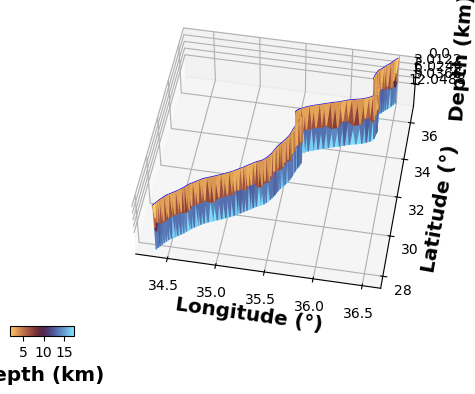

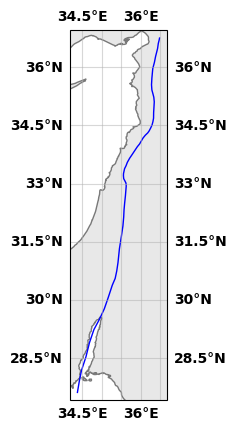

In [10]:
# Initialize the csi fault object
fault_DSF = csi.TriangularPatches('DSF', lon0=lon0, lat0=lat0)

# Read the fault trace and mesh from file
fault_DSF.file2trace("DataAndModels/tutoBlockModel/fault_DSF_trace.txt", header=0)
fault_DSF.readPatchesFromFile("DataAndModels/tutoBlockModel/fault_DSF_mesh.txt", readpatchindex=False, donotreadslip=True)

# We force all triangles to be considered vertical
fault_DSF.vertical = True

# Discetize the trace
fault_DSF.discretize(every=1., xaxis='y')

# Homogeneize the strike of the fault patches
fault_DSF.homogeneizeStrike(direction=0)

# Initialize the slip values on the fault patches
fault_DSF.initializeslip(values='depth')

# Plot parameters
fault_DSF.color = 'b'

# Plot
fault_DSF.plot(slip='strikeslip', cmap=cmc.managua, cblabel='depth (km)',
               view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4], plot_on_2d=False)

#### *Bitlis Zagros Suture*

---------------------------------
---------------------------------
Initializing fault BZS


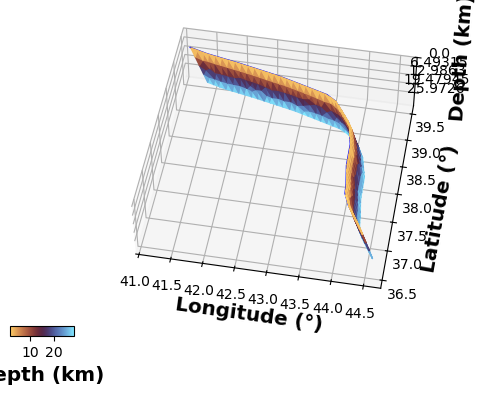

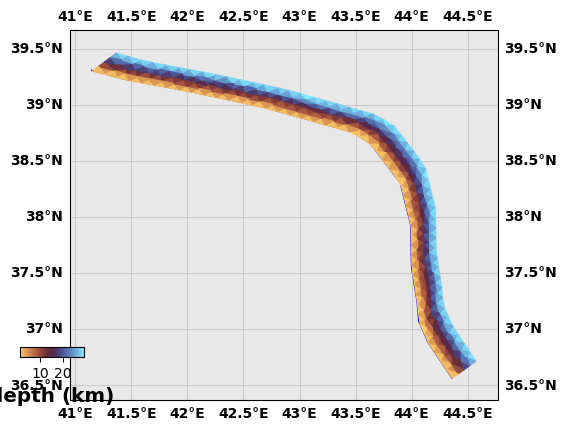

In [11]:
# Initialize the csi fault object
fault_BZS = csi.TriangularPatches('BZS', lon0=lon0, lat0=lat0)

# Read the fault trace and mesh from file
fault_BZS.file2trace("DataAndModels/tutoBlockModel/fault_BZS_trace.txt", header=0)
fault_BZS.readPatchesFromFile("DataAndModels/tutoBlockModel/fault_BZS_mesh.txt", readpatchindex=False, donotreadslip=True)

# Discetize the trace
fault_BZS.discretize(every=1., fracstep=.01)

# Homogeneize the strike of the fault patches
fault_BZS.homogeneizeStrike(direction=0)

# Initialize the slip values on the fault patches
fault_BZS.initializeslip(values='depth')

# Plot parameters
fault_BZS.color = 'b'

# Plot
fault_BZS.plot(slip='strikeslip', cmap=cmc.managua, cblabel='depth (km)',
               view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4], plot_on_2d=True)

#### *Cyprus subduction arc*

---------------------------------
---------------------------------
Initializing fault Cyprus arc


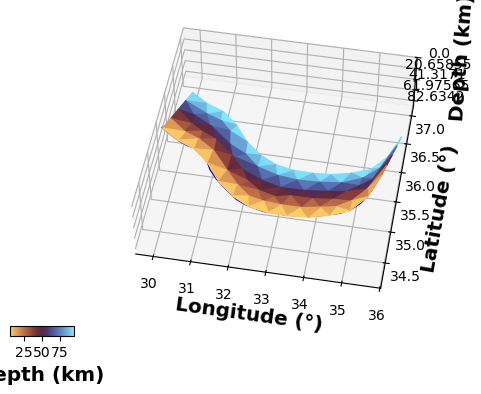

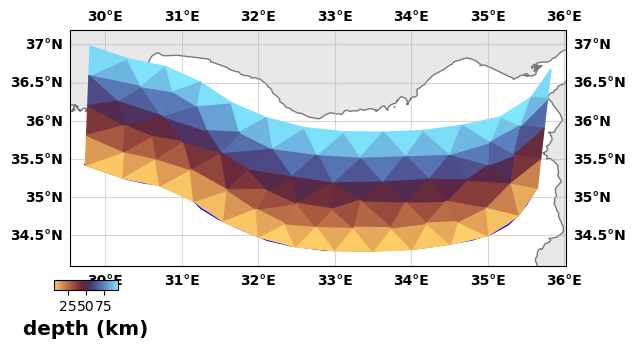

In [12]:
# Initialize the csi fault object
fault_Cyprus_arc = csi.TriangularPatches('Cyprus arc', lon0=lon0, lat0=lat0)

# Read the fault trace and mesh from file
fault_Cyprus_arc.file2trace("DataAndModels/tutoBlockModel/fault_Cyprus_arc_trace.txt", header=0)
fault_Cyprus_arc.readPatchesFromFile("DataAndModels/tutoBlockModel/fault_Cyprus_arc_mesh.txt", readpatchindex=False, donotreadslip=True)

# Discetize the trace
fault_Cyprus_arc.discretize(every=1.)

# Homogeneize the strike of the fault patches
fault_Cyprus_arc.homogeneizeStrike(direction=0)

# Initialize the slip values on the fault patches
fault_Cyprus_arc.initializeslip(values='depth')

# Plot parameters
fault_Cyprus_arc.color = 'b'

# Plot
fault_Cyprus_arc.plot(slip='strikeslip', cmap=cmc.managua, cblabel='depth (km)',
               view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4], plot_on_2d=True)

#### *Karasu Fault*

---------------------------------
---------------------------------
Initializing fault Karasu


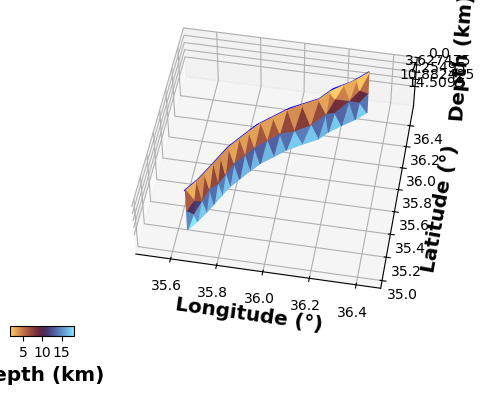

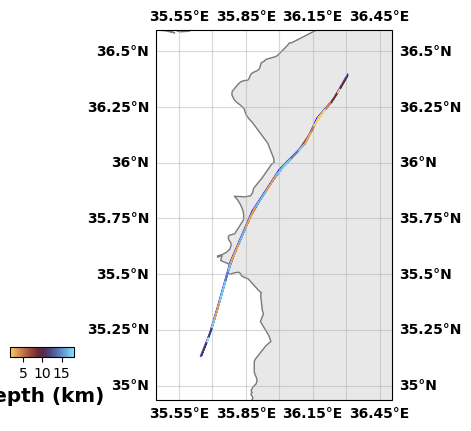

In [13]:
# Initialize the csi fault object
fault_Karasu = csi.TriangularPatches('Karasu', lon0=lon0, lat0=lat0)

# Read the fault trace and mesh from file
fault_Karasu.file2trace("DataAndModels/tutoBlockModel/fault_Karasu_trace.txt", header=0)
fault_Karasu.readPatchesFromFile("DataAndModels/tutoBlockModel/fault_Karasu_mesh.txt", readpatchindex=False, donotreadslip=True)

# We force all triangles to be considered vertical near the land
fault_Karasu.vertical = True

# Discetize the trace
fault_Karasu.discretize(every=1.)

# Homogeneize the strike of the fault patches
fault_Karasu.homogeneizeStrike(direction=0)

# Initialize the slip values on the fault patches
fault_Karasu.initializeslip(values='depth')

# Plot parameters
fault_Karasu.color = 'b'

# Plot
fault_Karasu.plot(slip='strikeslip', cmap=cmc.managua, cblabel='depth (km)',
               view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4], plot_on_2d=True)

#### *Concatenate faults*

In [14]:
Faults = [fault_EAF, fault_NAF, fault_DSF, fault_BZS, fault_Cyprus_arc, fault_Karasu]

### Setup MultiBlock

Here, we build the main object to deal with block modelling in csi...

---------------------------------
---------------------------------
Initializing multi block Turkey Block Model
---------------------------------
---------------------------------
Setting blocks for multi block Turkey Block Model
   Setting Block Arabia
   Setting Block Eurasia
   Setting Block Nubia
   Setting Block Anatolia
---------------------------------
---------------------------------
Setting block fault boundaries for multi block Turkey Block Model
   Setting Fault EAF: 600 / 600 patches
   Checking inconsistencies...
   Setting Fault NAF: 554 / 554 patches
   Checking inconsistencies...
   Setting Fault DSF: 426 / 426 patches
   Checking inconsistencies...
   Setting Fault BZS: 424 / 424 patches
   Checking inconsistencies...
   Setting Fault Cyprus arc: 122 / 122 patches
   Checking inconsistencies...
   Setting Fault Karasu: 72 / 72 patches
   Checking inconsistencies...


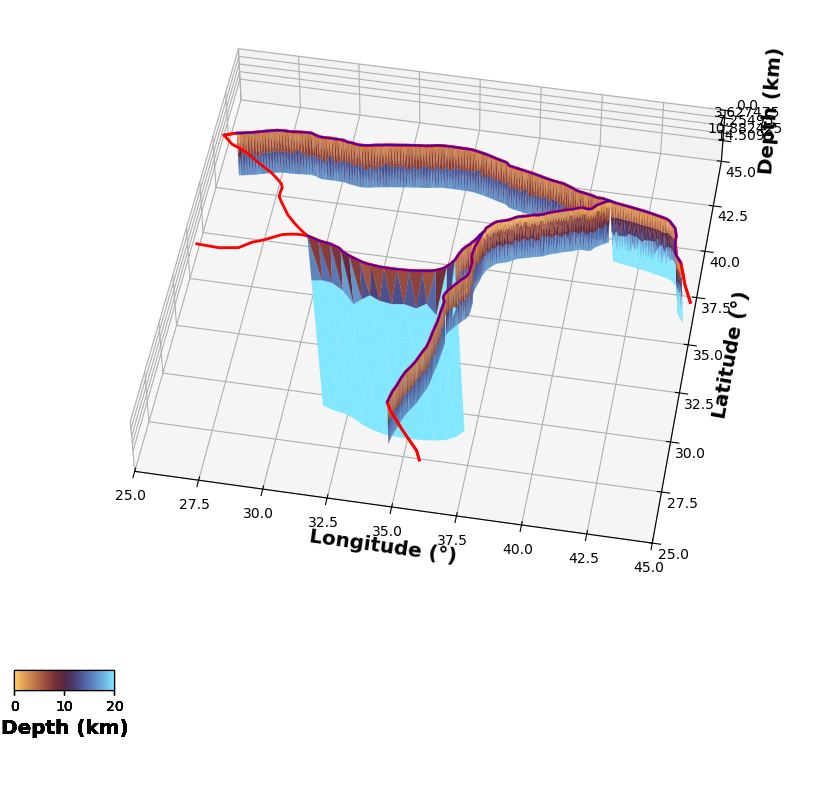

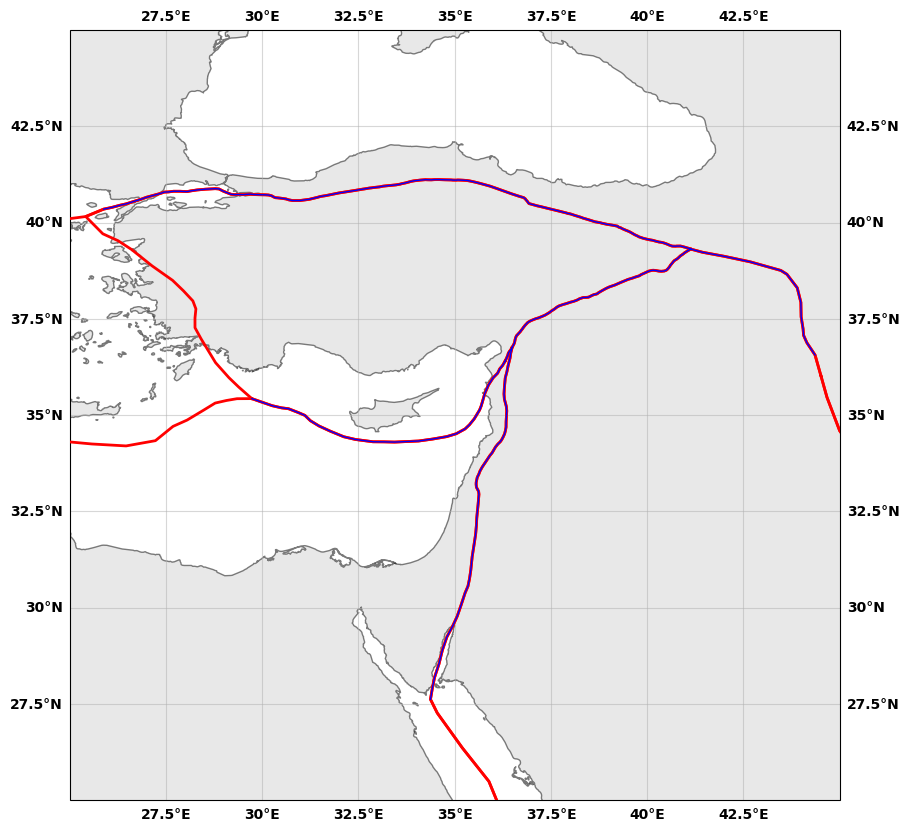

In [15]:
# Initialize the csi MultiBlock object
turkey_multiblocks = csi.MultiBlock(name='Turkey Block Model', lon0=lon0, lat0=lat0)

# Set the Blocks
# Be careful to give different names to each block (attribute 'name' of a csi.Block object)
turkey_multiblocks.setBlocks(blocks=Blocks)

# Set the block fault boundaries (associate for each fault patch the two blocks on each side of the patch)
# Be careful to give different names to each fault (attribute 'name' of a csi.Fault object)
# This function will look for the blocks on each side of each fault patch.
# You might need to adjust the parameter 'dist_step' (distance step for the search of the closest point on the block boundary)
# depending on the size of your blocks and the density of your fault mesh

# If this this the first time, run these functions
turkey_multiblocks.setBlockFaultBoundaries(faults=Faults)

# You can save the association to file to save time in the future
# turkey_multiblocks.saveBlockFaultBoundaries(outDir="DataAndModels/tutoBlockModel")

# If you have already run the function once, you can load the association from file to save time
# turkey_multiblocks.readBlockFaultBoundaries(faults=Faults, inDir="DataAndModels/tutoBlockModel")

# Plot
turkey_multiblocks.plot(slip='strikeslip', cmap=cmc.managua, cblabel='Depth (km)', norm=(0, 20),
                        view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.2], elinewidth=.1,
                        box=[25, 45, 25, 45], figsize=((10, 10), (10, 10)), plotPatches2d=False, npoints=None,
                        edgecolor='k', markersize=0)

If you want to check manually the association between blocks and fault patches, you can plot it:

In [16]:
# for fault in Faults:
    
#     print(f"Fault: {fault.name}")

#     fault.plot(slip='blockleft', cmap=cmc.managua, cblabel='Left block', norm=(0, turkey_multiblocks.Nblocks-1),
#                 view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4], figsize=((10, 10), None),
#                 Map=False, edgecolor='k', elinewidth=0.1, show=False, cbaxis=[0.1, 0.2, 0.3, 0.02])
#     fault.fig.cbax.ax.set_xticks(np.arange(0, turkey_multiblocks.Nblocks, 1), labels=[b.name for b in turkey_multiblocks.blocks])
#     fault.fig.show()

#     fault.plot(slip='blockright', cmap=cmc.managua, cblabel='Right block', norm=(0, turkey_multiblocks.Nblocks-1),
#                 view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4], figsize=((10, 10), None),
#                 Map=False, edgecolor='k', elinewidth=0.1, show=False, cbaxis=[0.1, 0.2, 0.3, 0.02])
#     fault.fig.cbax.ax.set_xticks(np.arange(0, turkey_multiblocks.Nblocks, 1), labels=[b.name for b in turkey_multiblocks.blocks])
#     fault.fig.show()

### Setup Transformation between Data

In an inversion, the fault object does not really care about reference frames. Furthermore, InSAR is a relative measurement. Therefore, you need to have some degree of freedom between the different datasets so they fall in the same reference frame. If you have carefully done that ahead, don't use a transformation object. However, as soon as you use InSAR, you should...

In [17]:
# Create csi transformation object
GeomTransformation = csi.transformation('Reference frame Corrections', lon0=lon0, lat0=lat0)

---------------------------------
---------------------------------
Initializing transformation Reference frame Corrections


## Setup Data

In this section, we import the geodetic data (GNSS & InSAR) that are processd for the inversion. You can have a look at the other tutorials to prepare the data for the inversion.

### GNSS

The GNSS interseismic velocity field is a combination of three previsouly published compilations ([Ergintav et al., 2023](https://doi.org/10.55730/1300-0985.1842), [Özbey et al., 2024](https://doi.org/10.1051/bsgf/2024012), [Castro-Perdomo et al., 2025](https://doi.org/10.1029/2025JB031738) and references therein).

---------------------------------
---------------------------------
Initialize GPS array GNSS network
Read data from file DataAndModels/tutoBlockModel/data_gnss_eurasia_fixed.txt into data set GNSS network
Cannot plot ellipses or quiverkey if scale is None


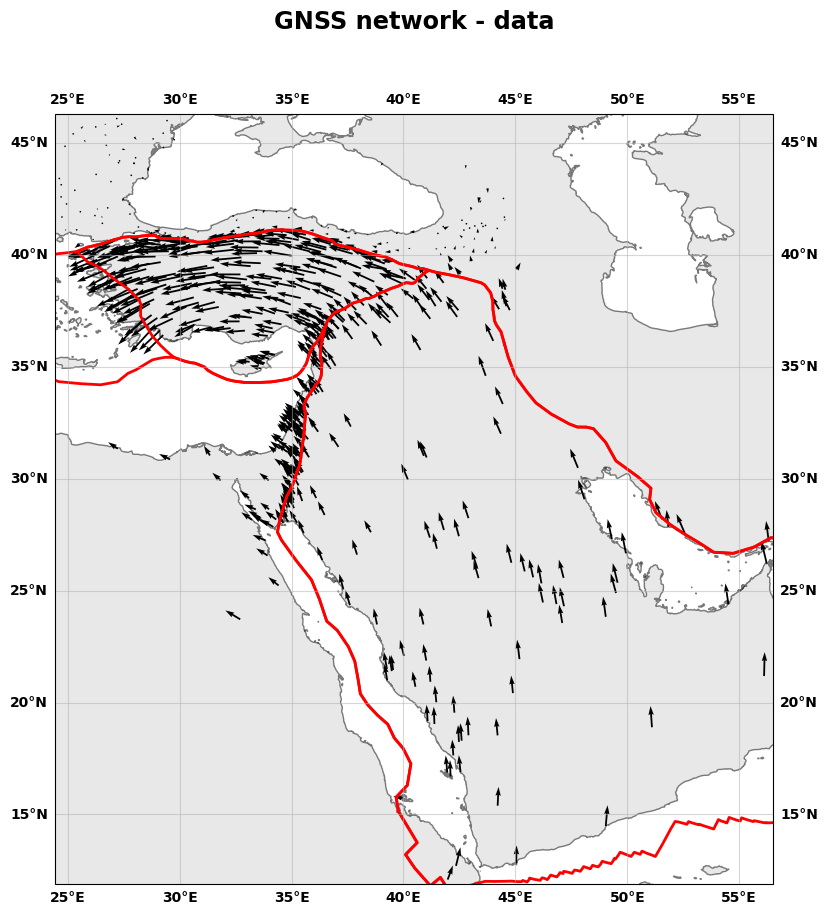

In [18]:
# Initialize the csi GNSS object
gnss_net = csi.gps('GNSS network', lon0=lon0, lat0=lat0)

# Read the GNSS data
gnss_net.read_from_enu(f"DataAndModels/tutoBlockModel/data_gnss_eurasia_fixed.txt",
                        factor=1., header=1, checkNaNs=False)

# We don't consider the vertical component
gnss_net.vel_enu[:, 2] = np.nan

# Associate each GNSS station to a block
gnss_net.getBlockList(Blocks)

# Build the covariance matrix
gnss_net.buildCd(direction='en')

# Plot
gnss_net.plot(figsize=(10, 10), faults=Faults, blocks=Blocks,
              legendscale=10, width=0.0025, title=gnss_net.name)

# We gather the GNSS data in a single vector
GNSSs = [gnss_net]

### Setup InSAR Data

The InSAR interseismic velocity fields are post-processed from time series of the [FLATSIM project](https://www.poleterresolide.fr/le-service-flatsim/). The velocity maps have already been downsampled, and the covariance has been computed in non-deforming regions.

---------------------------------
---------------------------------
Initialize InSAR data set InSAR TUR-A043
Read from file DataAndModels/tutoBlockModel/data_insar_TUR-A043 into data set InSAR TUR-A043


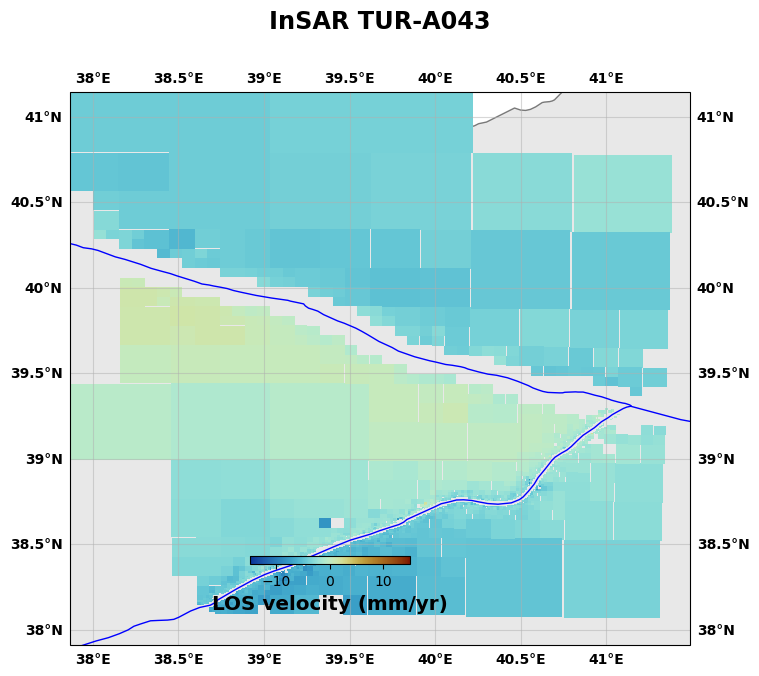

---------------------------------
---------------------------------
Initialize InSAR data set InSAR TUR-A116
Read from file DataAndModels/tutoBlockModel/data_insar_TUR-A116 into data set InSAR TUR-A116


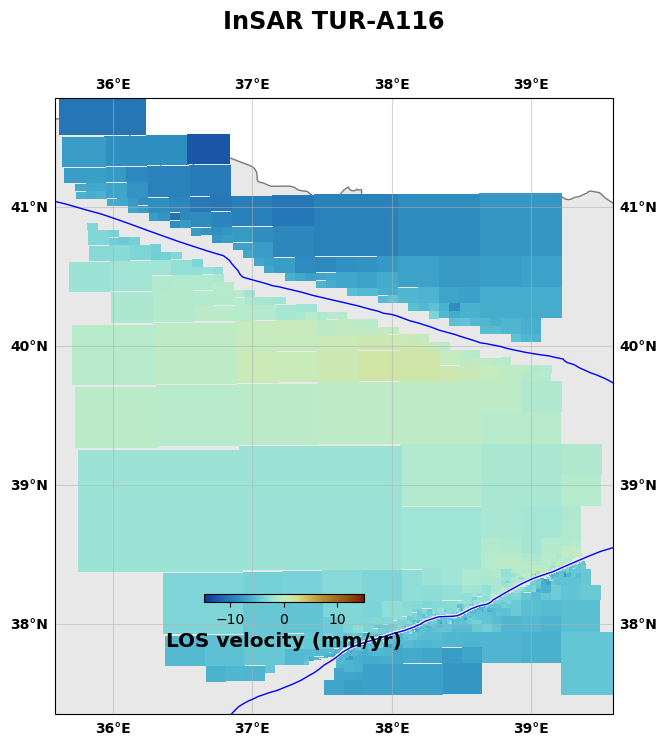

---------------------------------
---------------------------------
Initialize InSAR data set InSAR TUR-D021
Read from file DataAndModels/tutoBlockModel/data_insar_TUR-D021 into data set InSAR TUR-D021


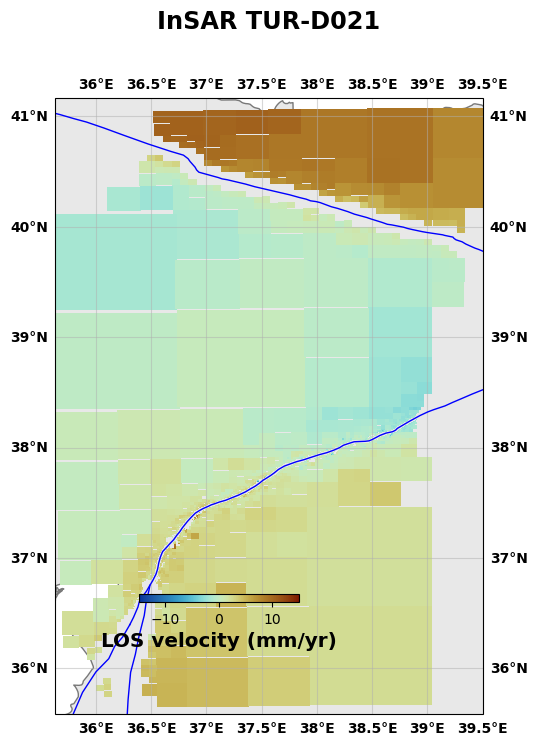

---------------------------------
---------------------------------
Initialize InSAR data set InSAR TUR-D123
Read from file DataAndModels/tutoBlockModel/data_insar_TUR-D123 into data set InSAR TUR-D123


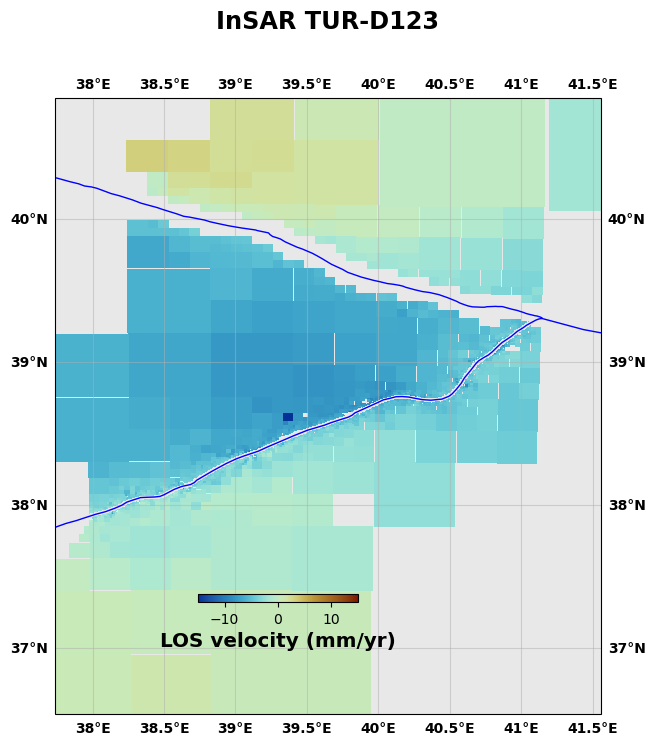

In [19]:
# List of the InSAR track names
list_tracks = ['TUR-A043', 'TUR-A116', 'TUR-D021', 'TUR-D123']

# Vector to store the InSAR data
InSARs = []

for track in list_tracks:
    
    # Initialize the csi InSAR object
    sar = csi.insar(name=f"InSAR {track}", lon0=lon0, lat0=lat0)
    
    # Read the downsampled data
    sar.read_from_varres(f"DataAndModels/tutoBlockModel/data_insar_{track}",
                         factor=1., step=0., header=2, cov=False)
    
    # To respect the convention of csi, we multiply the LOS velocity by -1
    sar.los *= -1
    
    # Get the block list (for each InSAR pixel, we associate the block in which it is located)
    sar.getBlockList(Blocks)

    # Build the data covariance matrix from the covariance
    sigma_ = [float(line.split()[-1]) for line in open(f"DataAndModels/tutoBlockModel/data_insar_{track}.cov", 'r').readlines() if line.split()[1]=='Sigma'][0] 
    lambda_ = [float(line.split()[-1]) for line in open(f"DataAndModels/tutoBlockModel/data_insar_{track}.cov", 'r').readlines() if line.split()[1]=='Lambda'][0]
    std_ = float(np.loadtxt(f"DataAndModels/tutoBlockModel/data_insar_{track}.std"))
    sar.buildCd(sigma=sigma_, lam=lambda_, function='exp')
    np.fill_diagonal(sar.Cd, std_**2)
    
    # Plot
    sar.plot(plotType='decimate', faults=Faults, norm=[-15, 15], figsize=(8, 8), edgewidth=0.0,
                 cmap=cmc.roma_r, cbaxis=[.35, .25, 0.2, 0.01], cblabel='LOS velocity (mm/yr)', title=sar.name)
    
    # Store this InSAR object
    InSARs.append(sar)

del sar

### Merge Data

We gather all the data in one object.

In [20]:
Datas = GNSSs + InSARs

## Build the Green's functions

In this section, we build the Green's functions for each dataset and deformation source.

### Transformation between Data

In [21]:
# GNSS data
for gnss in GNSSs:
    
    # Compute the Green's functions
    # No transformation for GNSS data, it is the reference
    GeomTransformation.buildGFs(gnss, transformations=[None])
    
    # If you have saved the Green's functions, you can load them from file to save time
    # GeomTransformation.setGFsFromFile(gnss, vertical=False, inDir=f"DataAndModels/tutoBlockModel/gf")

# InSAR data
for sar in InSARs:

    # Compute the Green's functions
    # For each InSAR track, we estimate a polynomial transformation: a + bx + cy
    GeomTransformation.buildGFs(sar, transformations=['1_x_y'])
    
    # If you have saved the Green's functions, you can load them from file to save time
    # GeomTransformation.setGFsFromFile(sar, vertical=True, inDir=f"DataAndModels/tutoBlockModel/gf")

# If you want to save the Green's functions to file to save time in the future, you can run the following command
# GeomTransformation.saveGFs(outputDir=f"DataAndModels/tutoBlockModel/gf")

---------------------------------
---------------------------------
Building transformation Green's functions
for the data set GNSS network of type gps
---------------------------------
---------------------------------
Building transformation Green's functions
for the data set InSAR TUR-A043 of type insar
---------------------------------
---------------------------------
Building transformation Green's functions
for the data set InSAR TUR-A116 of type insar
---------------------------------
---------------------------------
Building transformation Green's functions
for the data set InSAR TUR-D021 of type insar
---------------------------------
---------------------------------
Building transformation Green's functions
for the data set InSAR TUR-D123 of type insar


### Fault

We use the Meade solution for triangular dislocation in an elastic halfspace. We are only interested by coupling along the East Anatolian Fault, so we only compute the Green's functions for the East Anatolian Fault.

In [22]:
# GNSS data
for gnss in GNSSs:
    
    # Compute the Green's functions
    fault_EAF.buildGFs(gnss, slipdir='sdt', method='meade', vertical=False)
    
    # If you have saved the Green's functions, you can load them from file to save time
    # fault_EAF.setGFsFromFile(gnss, vertical=False, inDir=f"DataAndModels/tutoBlockModel/gf")

# InSAR data
for sar in InSARs:
    
    # Compute the Green's functions
    fault_EAF.buildGFs(sar, slipdir='sdt', method='meade', vertical=True)

    # If you have saved the Green's functions, you can load them from file to save time
    # fault_EAF.setGFsFromFile(sar, vertical=True, inDir=f"DataAndModels/tutoBlockModel/gf")

# If you want to save the Green's functions to file to save time in the future, you can run the following command
# fault_EAF.saveGFs(outputDir=f"DataAndModels/tutoBlockModel/gf")

Greens functions computation method: meade
---------------------------------
---------------------------------
Building Green's functions for the data set 
GNSS network of type gps in a homogeneous half-space
 Patch: 600 / 600  
Greens functions computation method: meade
---------------------------------
---------------------------------
Building Green's functions for the data set 
InSAR TUR-A043 of type insar in a homogeneous half-space
 Patch: 600 / 600  
Greens functions computation method: meade
---------------------------------
---------------------------------
Building Green's functions for the data set 
InSAR TUR-A116 of type insar in a homogeneous half-space
 Patch: 600 / 600  
Greens functions computation method: meade
---------------------------------
---------------------------------
Building Green's functions for the data set 
InSAR TUR-D021 of type insar in a homogeneous half-space
 Patch: 600 / 600  
Greens functions computation method: meade
-----------------------------

### MultiBlock

We use the Meade solution for triangular dislocation in an elastic halfspace for the backslip. The intrablock deformation is defined as a uniform strain on a sphere.

In [23]:
# GNSS data
for gnss in GNSSs:
    
    # Compute the Green's functions
    # Rotation of blocks + backslip at boundaries + intrablock deformation
    turkey_multiblocks.buildGFs(gnss, method='rotation+boundary+intradef', blockslipdir='sdt', vertical=False)

    # If you have saved the Green's functions, you can load them from file to save time
    # turkey_multiblocks.setGFsFromFile(gnss, vertical=False, inDir=f"DataAndModels/tutoBlockModel/gf")

# InSAR data
for sar in InSARs:
    
    # Compute the Green's functions
    # Rotation of blocks + backslip at boundaries + intrablock deformation
    turkey_multiblocks.buildGFs(sar, method='rotation+boundary+intradef', blockslipdir='sdt', vertical=True)
    
    # If you have saved the Green's functions, you can load them from file to save time
    # turkey_multiblocks.setGFsFromFile(sar, vertical=True, inDir=f"DataAndModels/tutoBlockModel/gf")

# If you want to save the Green's functions to file to save time in the future, you can run the following command
# turkey_multiblocks.saveGFs(outputDir=f"DataAndModels/tutoBlockModel/gf")

---------------------------------
---------------------------------
Building blocks rotation Green's functions
for the data set GNSS network of type gps
---------------------------------
---------------------------------
Building internal blocks deformation Green's functions
for the data set GNSS network of type gps
---------------------------------
---------------------------------
Building boundary blocks deformation Green's functions
for the data set GNSS network of type gps
 Building boundary EAF: patch 600 / 600 
 Building boundary NAF: patch 554 / 554 
 Building boundary DSF: patch 426 / 426 
 Building boundary BZS: patch 424 / 424 
 Building boundary Cyprus arc: patch 122 / 122 
 Building boundary Karasu: patch 72 / 72 
---------------------------------
---------------------------------
Building blocks rotation Green's functions
for the data set InSAR TUR-A043 of type insar
---------------------------------
---------------------------------
Building internal blocks deformation G

## Play with synthetics

In this section, we present some simple examples of how to use a block model to generate predictions of GNSS and InSAR velocity fields, and explore the parameter space.

### Rotation

We start with the simplest case, in which we only consider the rigid rotation of the blocks on the Earth's surface.

To define a block model, you need to start with the rotation vectors for each block. You can define them either using an Euler pole and a rotation rate, or directly using the Cartesian rotation vector (3 parameters per block).

In [24]:
# We use the Euler pole coordinates and the rotation rate here, you can use deg/Myr or mas/yr as a unit for rotation rates.
# CSI deals with the rotation rates in rad/yr internally, so the conversion is done automatically when you set the rotation parameters.
# I don't set the rotation parameters for Eurasia since the GNSS data are in the Eurasia reference frame
block_africa.set_rotation(pole_lon=9.12, pole_lat=-6.07, rot_rate=0.12e3, unit='deg/Myr')
block_arabia.set_rotation(pole_lon=7.29, pole_lat=9.79, rot_rate=0.204e3, unit='deg/Myr')
block_anatolia.set_rotation(pole_lon=32.95, pole_lat=27.50, rot_rate=0.971e3, unit='deg/Myr')

# You could also use the Cartesian rotation vector (same choice for the units)
# block_africa.set_rotation(omega_x=118, omega_y=19, omega_z=-13, unit='deg/Myr')
# block_arabia.set_rotation(omega_x=200, omega_y=26, omega_z=35, unit='deg/Myr')
# block_anatolia.set_rotation(omega_x=723, omega_y=469, omega_z=448, unit='deg/Myr')

It's interesting to look at the long-term slip rates predicted by the block model for faults.

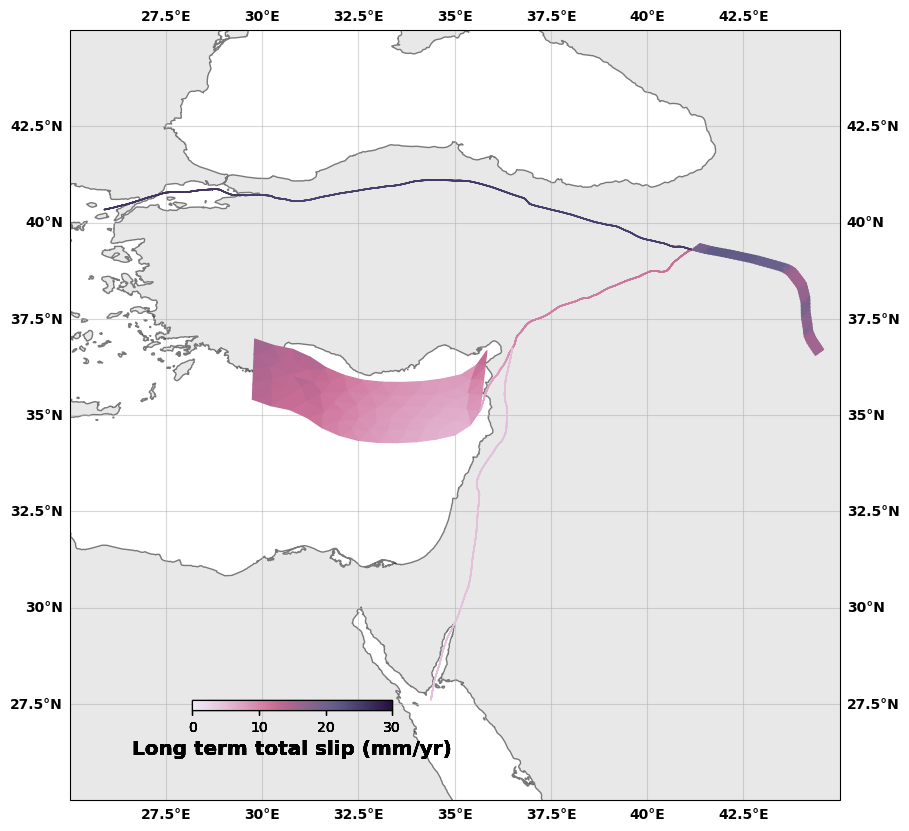

In [25]:
# We compute the long-term slip rate on the faults from the block rotations
turkey_multiblocks.GetLongTermSlipRate()

# We show the different components of the slip

# strike slip
# turkey_multiblocks.plot(slip='longtermstrikeslip', cmap=cmc.vik, cblabel='Long term strike slip (mm/yr)', norm=(-30, 30),
#                         view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4],
#                         box=[25, 45, 25, 45], figsize=((10, 10), (10, 10)), Fault=False, cbaxis=[.25, .2, 0.2, 0.01],
#                         plotBlockBoundaries2d=False)

# dip slip
# turkey_multiblocks.plot(slip='longtermdipslip', cmap=cmc.vik, cblabel='Long term dip slip (mm/yr)', norm=(-30, 30),
#                         view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4],
#                         box=[25, 45, 25, 45], figsize=((10, 10), (10, 10)), Fault=False, cbaxis=[.25, .2, 0.2, 0.01],
#                         plotBlockBoundaries2d=False)

# tensile slip
# turkey_multiblocks.plot(slip='longtermtensileslip', cmap=cmc.vik, cblabel='Long term tensile slip (mm/yr)', norm=(-30, 30),
#                         view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4],
#                         box=[25, 45, 25, 45], figsize=((10, 10), (10, 10)), Fault=False, cbaxis=[.25, .2, 0.2, 0.01],
#                         plotBlockBoundaries2d=False)

# total slip
turkey_multiblocks.plot(slip='longtermtotalslip', cmap=cmc.acton_r, cblabel='Long term total slip (mm/yr)', norm=(0, 30),
                        view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4],
                        box=[25, 45, 25, 45], figsize=((10, 10), (10, 10)), Fault=False, cbaxis=[.25, .2, 0.2, 0.01],
                        plotBlockBoundaries2d=False)

We compute the predictions and compare them with the GNSS velocity field.

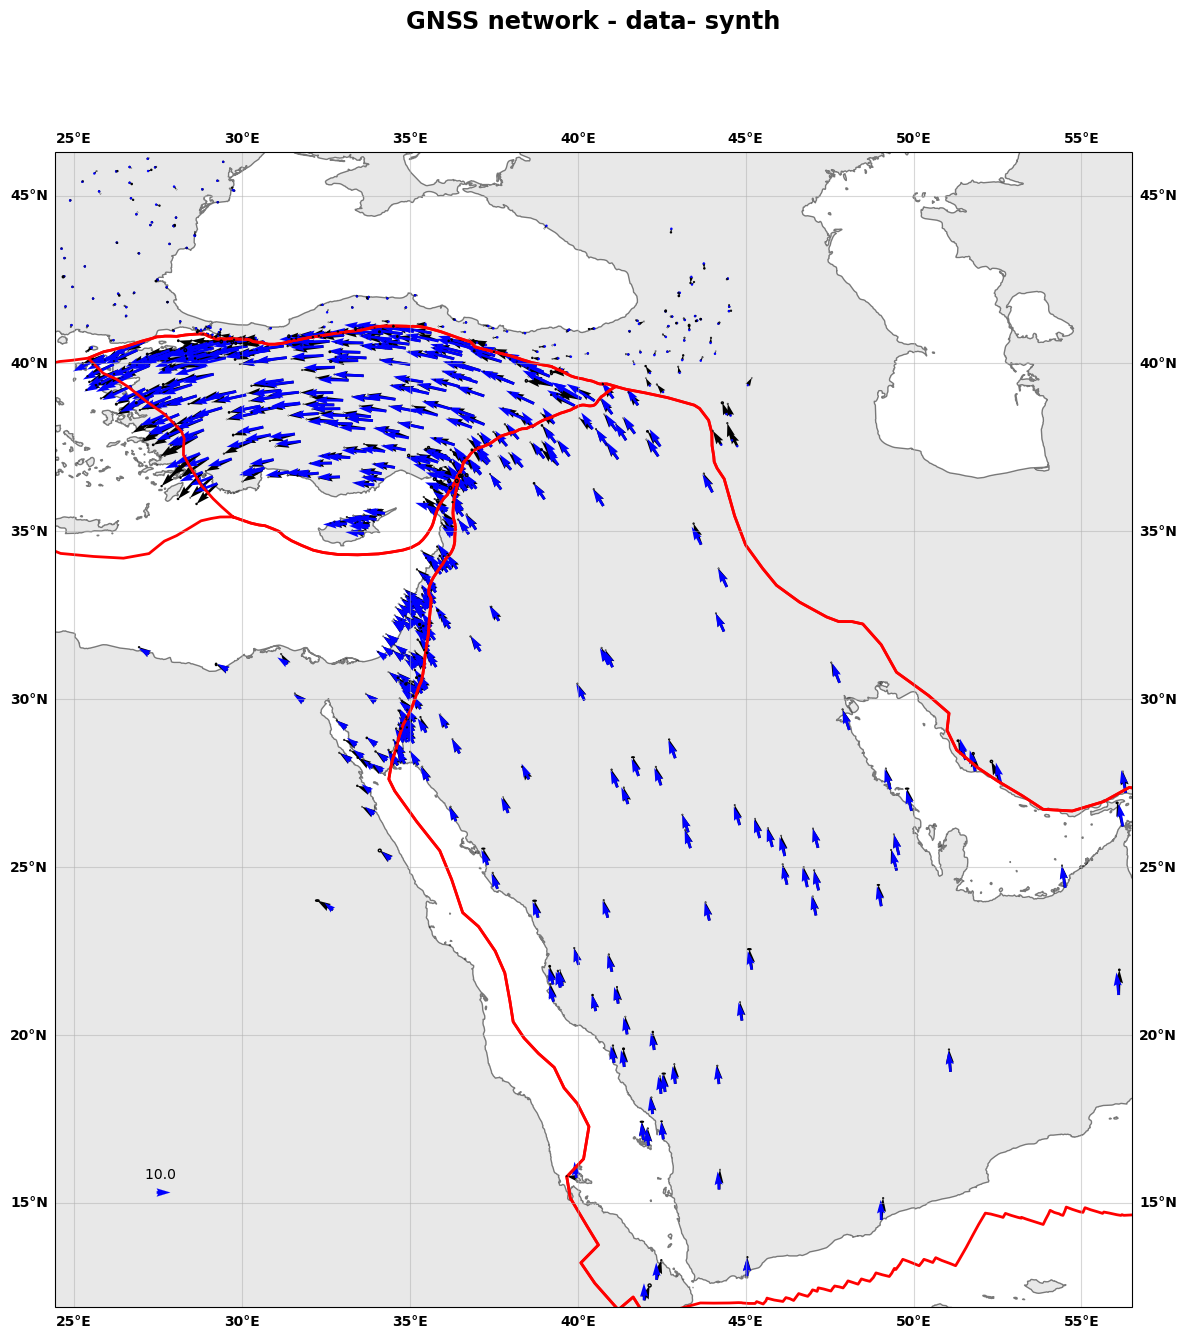

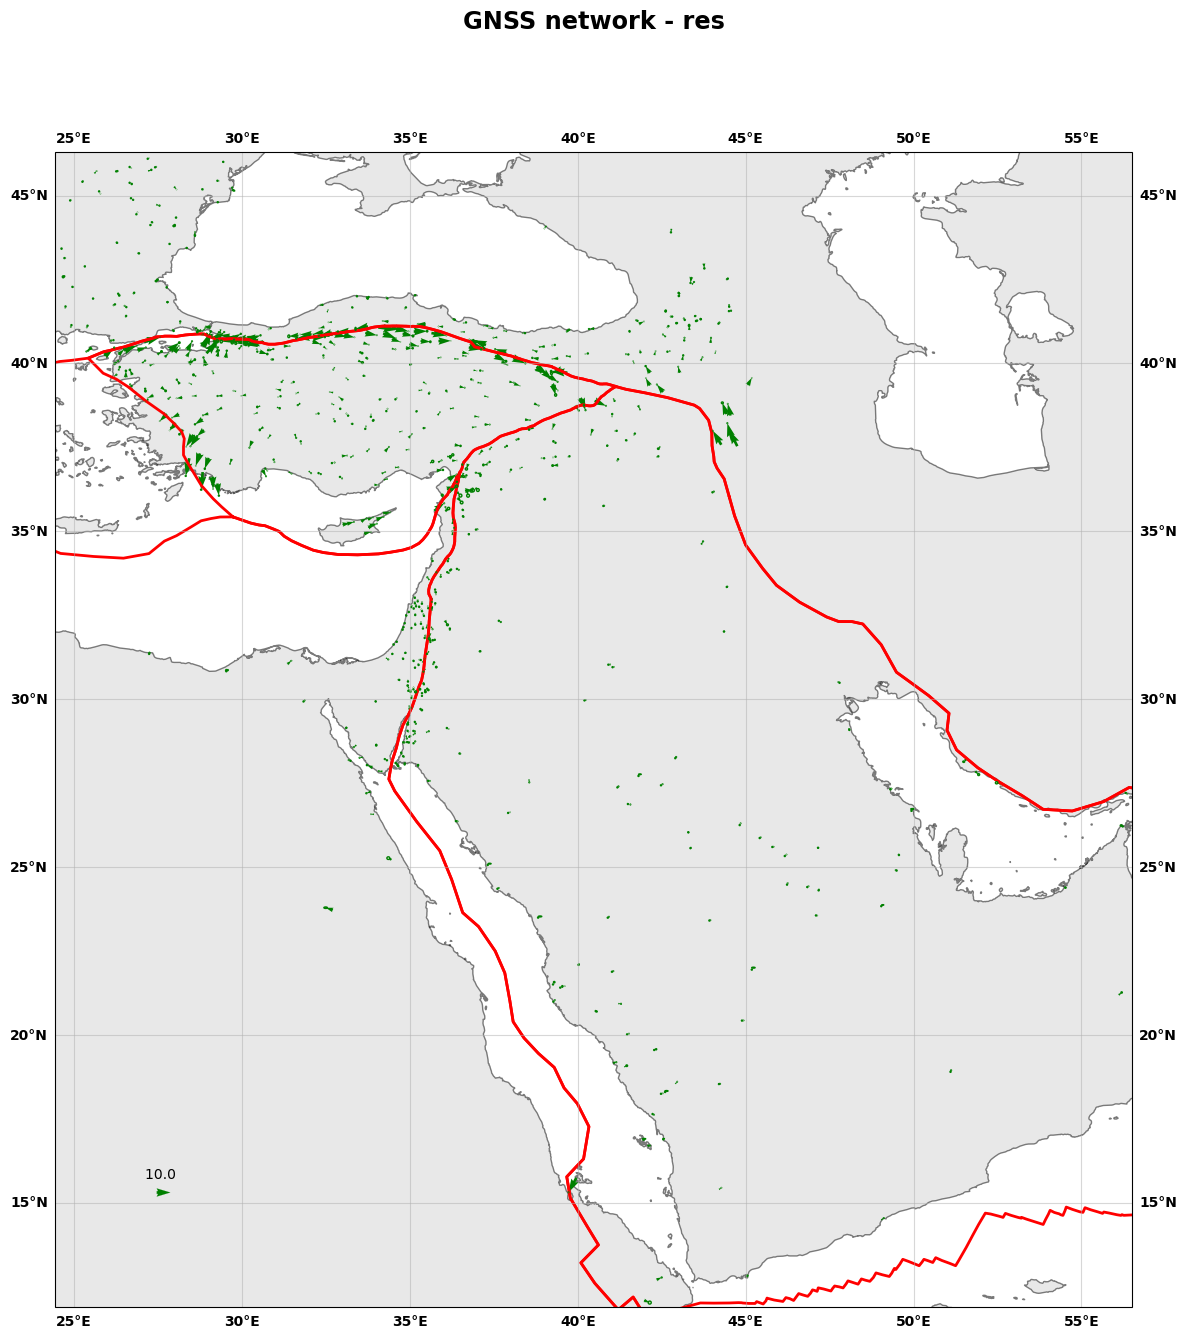

In [26]:
for gnss in GNSSs:
    
    # We build the synthetic data for the GNSS stations
    gnss.buildsynth([turkey_multiblocks], blockcomponent='rotation')
    
    # We show the GNSS data, the synthetic data and the residuals
    gnss.plot(data=['data', 'synth'], color=['k', 'b'], figsize=(15, 15), scale=25., blocks=Blocks, width=0.0025)
    gnss.plot(data=['res'], color=['g'], figsize=(15,15), scale=25., blocks=Blocks, width=0.0025)

The model works well for the blocks' interiors, but it's clear that it doesn't account for the deformation near the faults.

### Rotation + elastic deformation from faults

To account for the elastic deformation due to fault slip imposed by the relative motion of the blocks, we simply need to change one argument when calculating the synthetics.

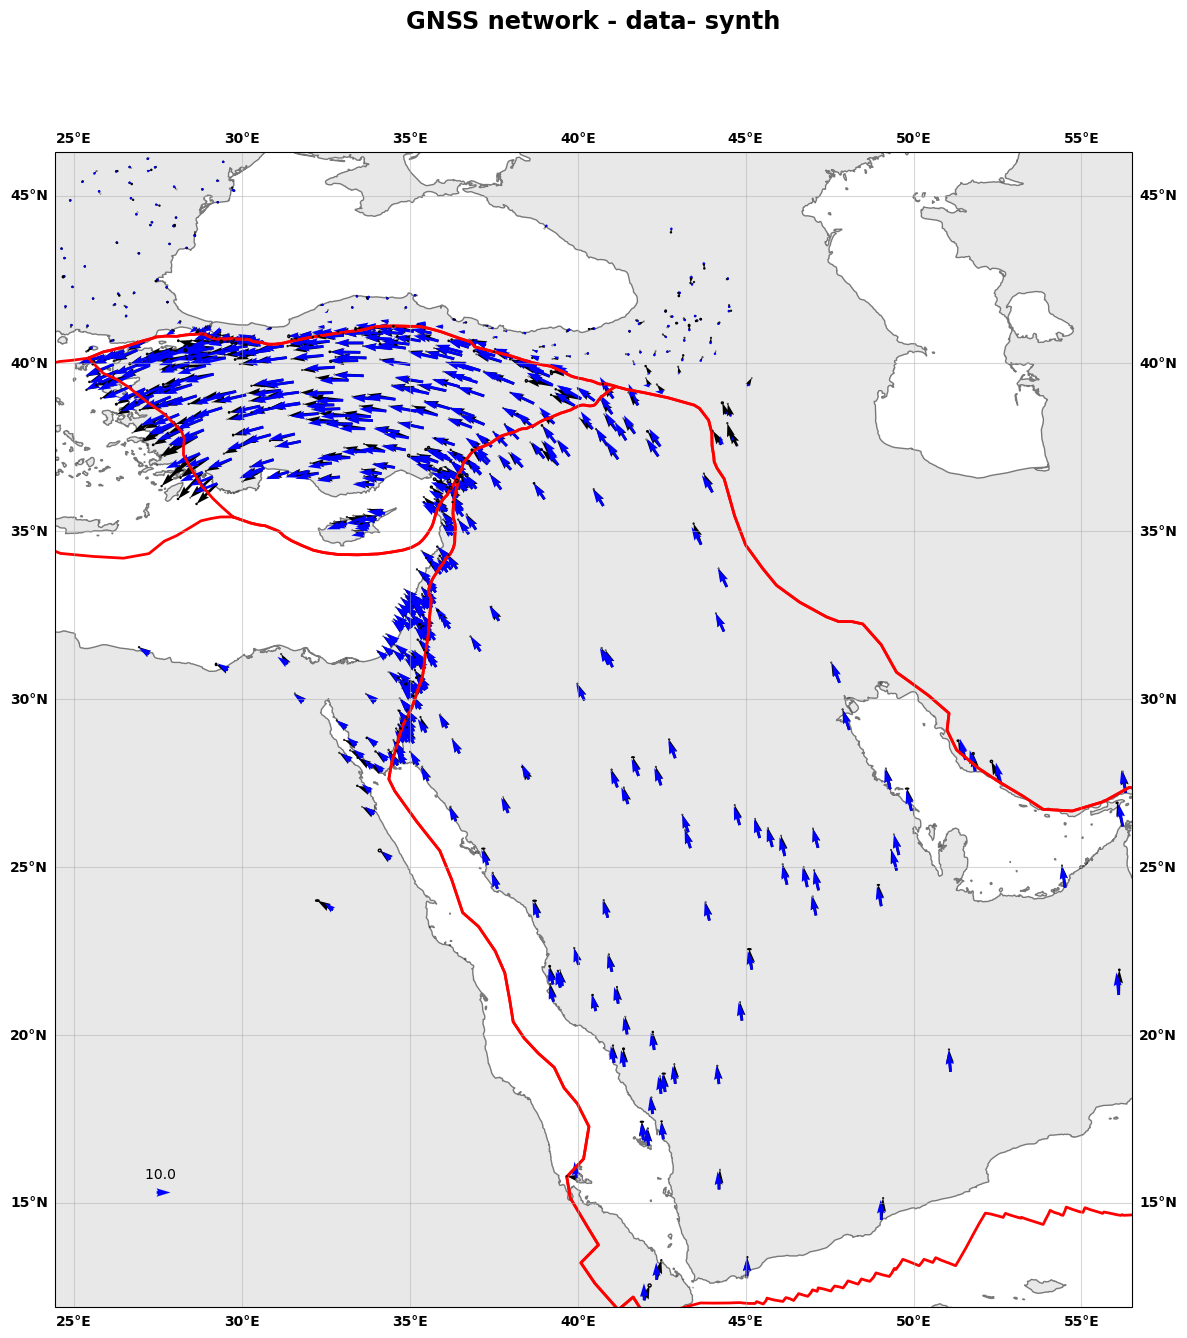

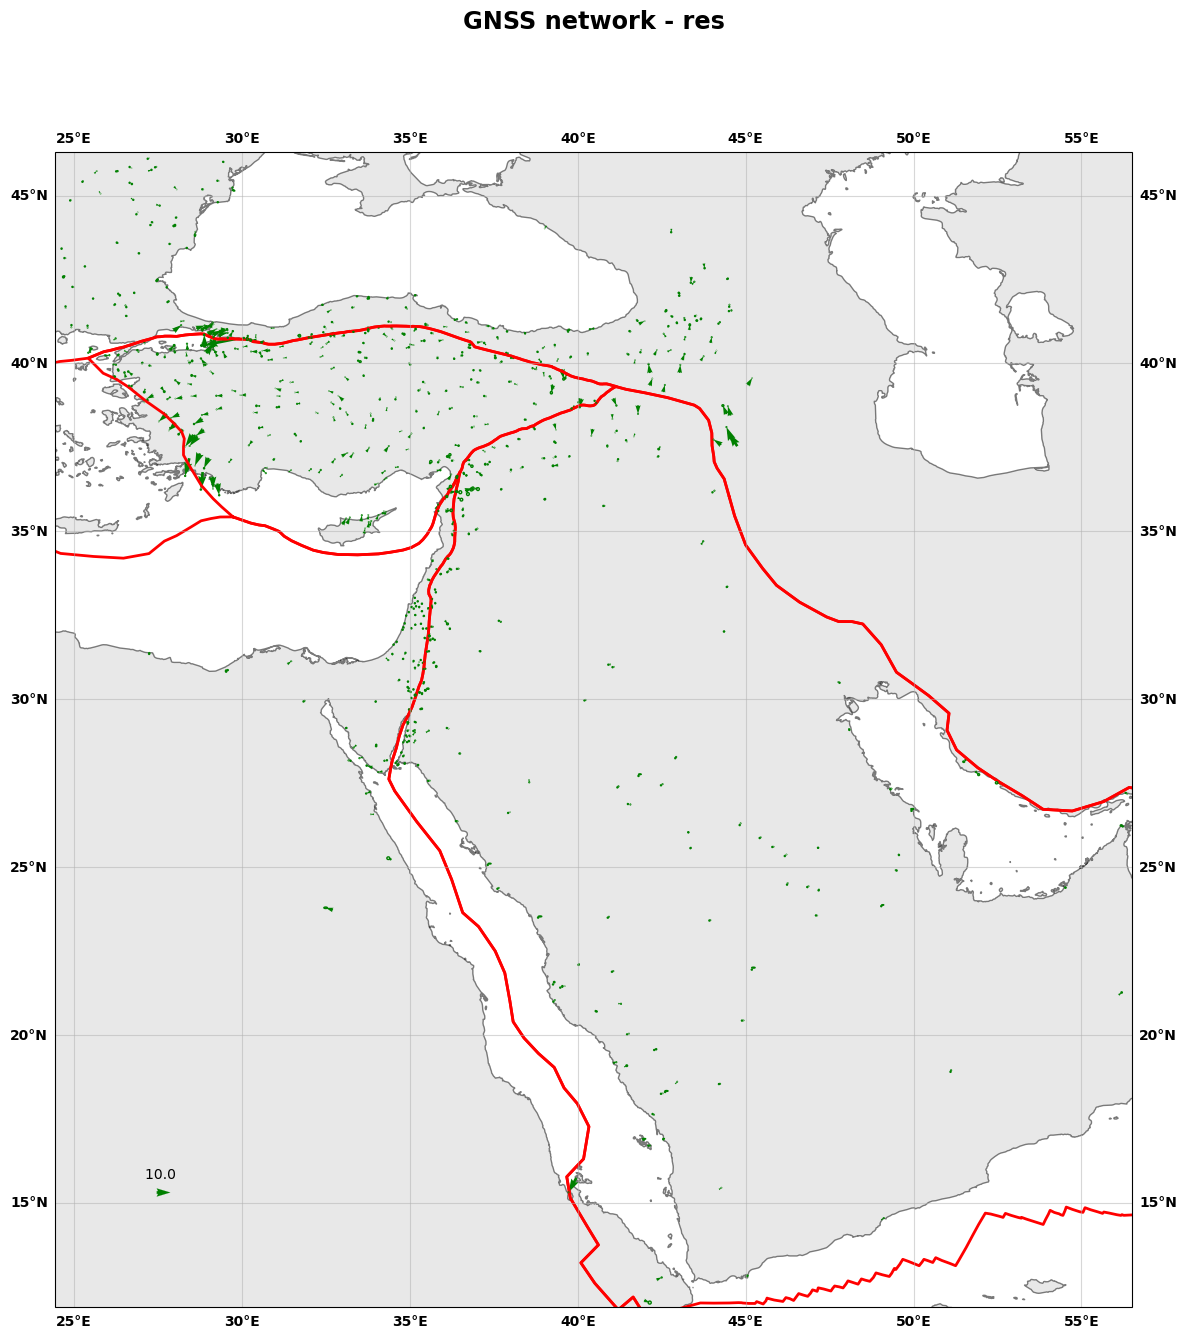

In [27]:
for gnss in GNSSs:
    
    # We build the synthetic data for the GNSS stations
    gnss.buildsynth([turkey_multiblocks], blockcomponent='rotation+boundary')
    
    # We show the GNSS data, the synthetic data and the residuals
    gnss.plot(data=['data', 'synth'], color=['k', 'b'], figsize=(15, 15), scale=25., blocks=Blocks, width=0.0025)
    gnss.plot(data=['res'], color=['g'], figsize=(15,15), scale=25., blocks=Blocks, width=0.0025)

The fit is now much better!

### Rotation + elastic deformation from faults + intrablock deformation

It is also possible to add internal strain to the block. This is represented by a uniform strain on a sphere. It is defined with a horizontal strain rate tensor (3 parameters per block).

In [28]:
# The three component sof the intrablock strain rate tensor must be given in nstrain/time unit (here nstrain/yr).
# To use the intrablock deformation, you need to compute the reference point (centroid) of the block beforehand, like this:
# block_arabia.setRefPoint()
block_arabia.setStrainTensor(eps_lonlon=5e3, eps_latlat=5e3, eps_lonlat=1e3)

We compute the predictions and compare them with the GNSS velocity field.

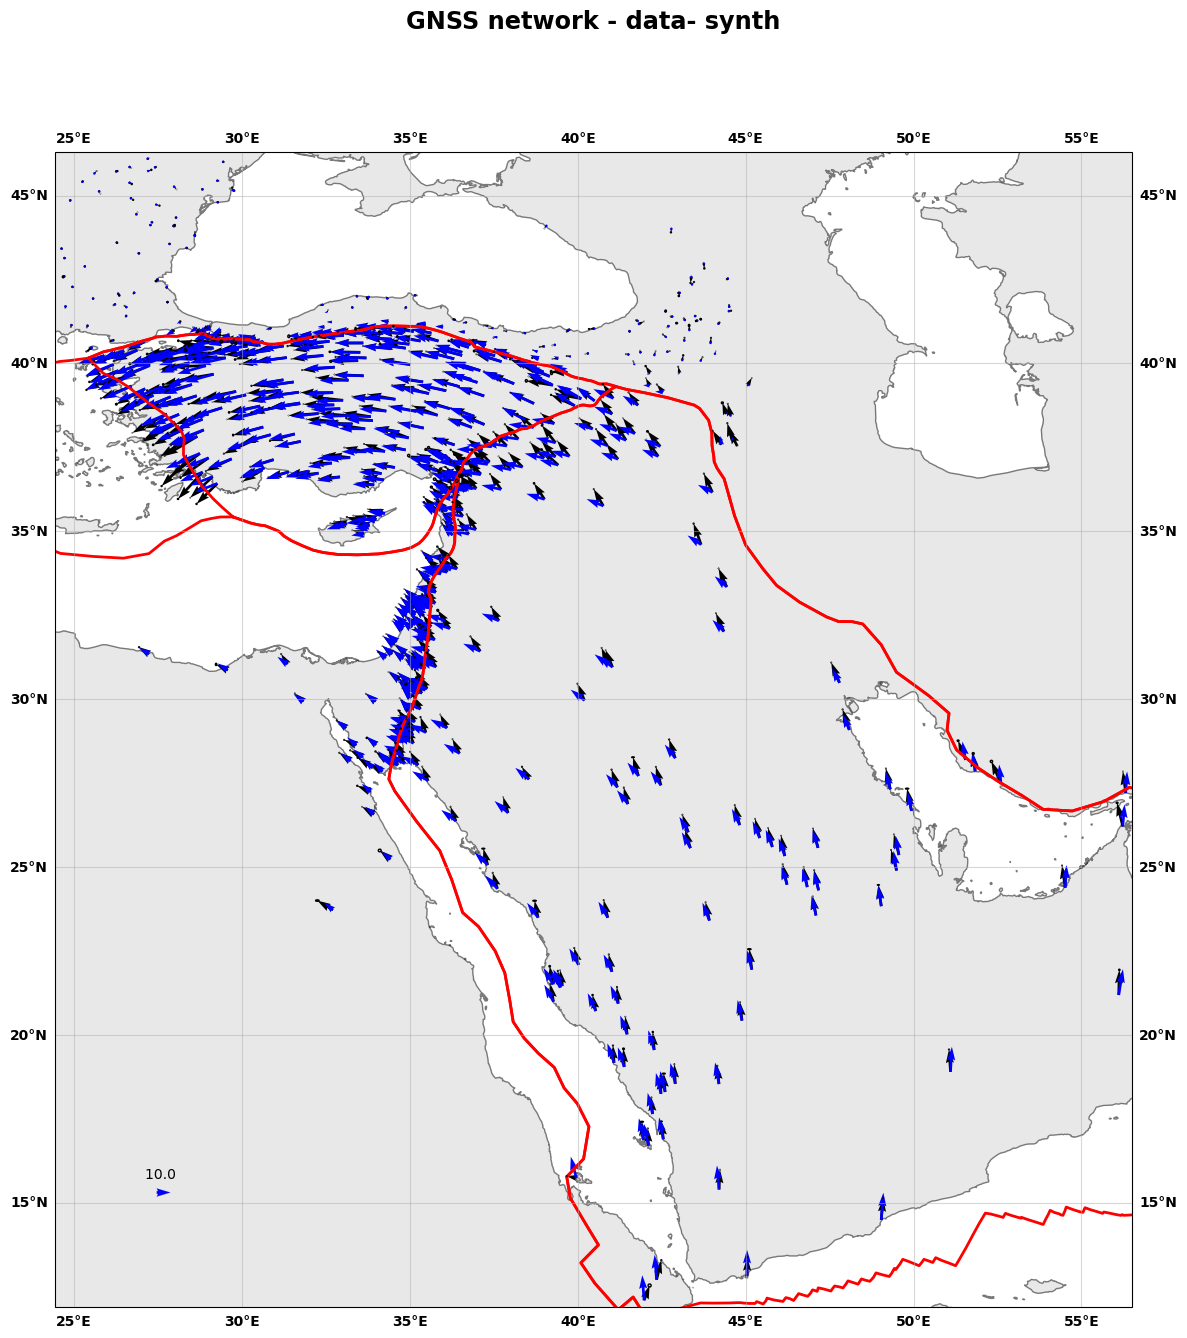

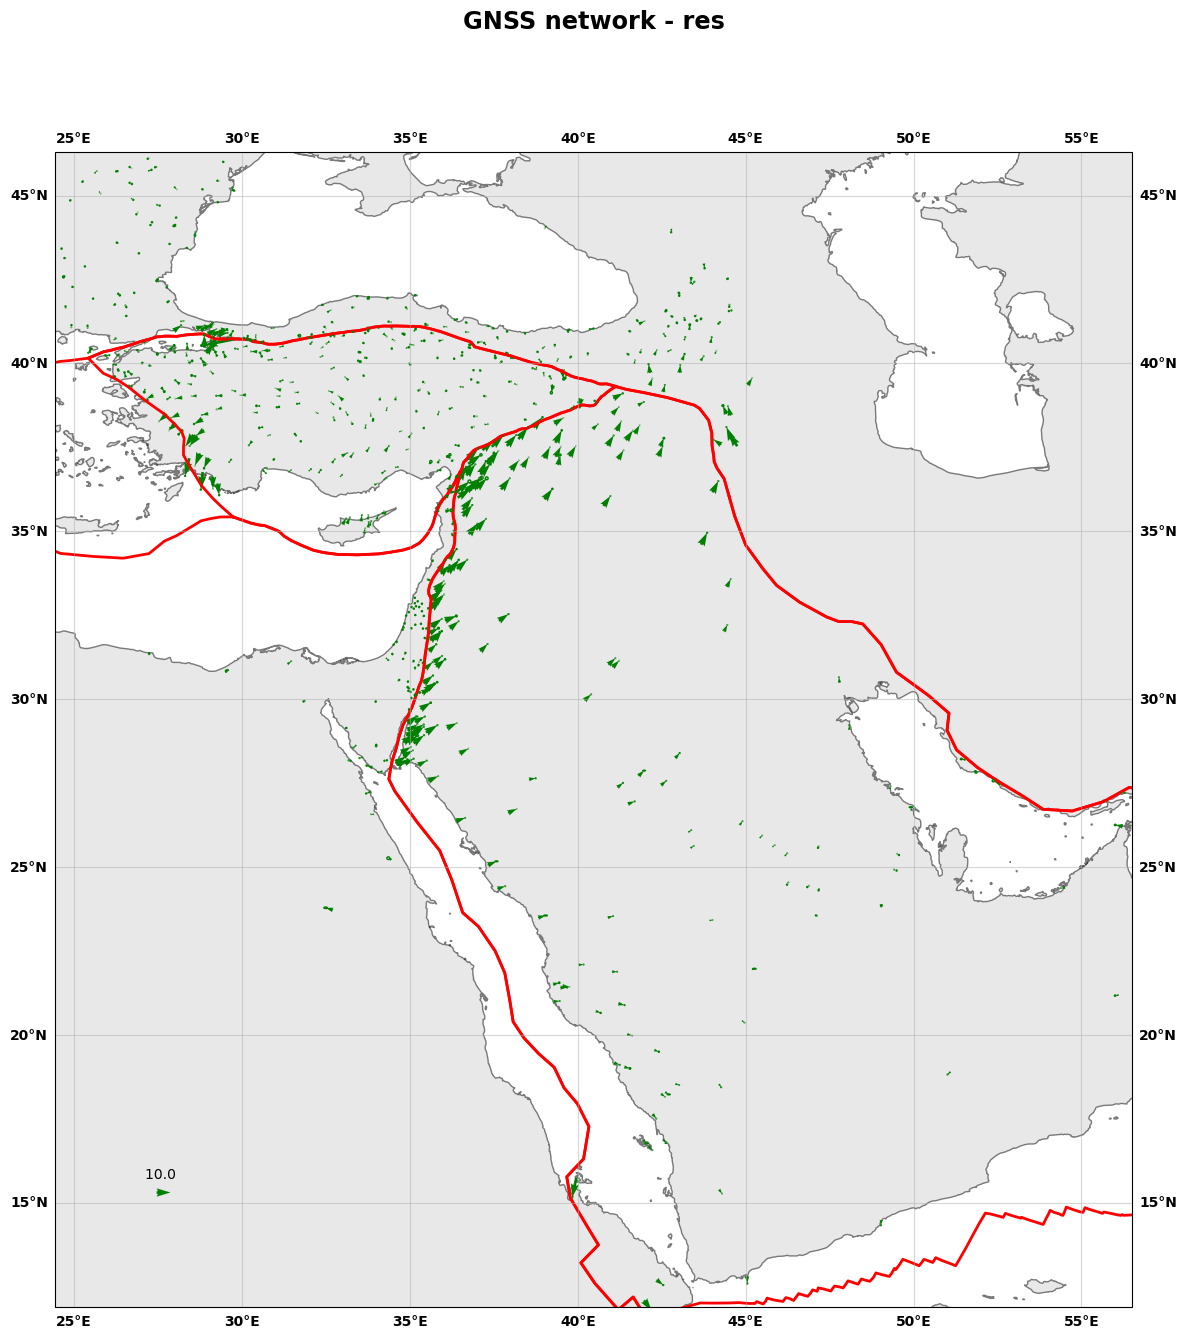

In [29]:
for gnss in GNSSs:
    
    # We build the synthetic data for the GNSS stations
    gnss.buildsynth([turkey_multiblocks], blockcomponent='rotation+boundary+intradef')
    
    # We show the GNSS data, the synthetic data and the residuals
    gnss.plot(data=['data', 'synth'], color=['k', 'b'], figsize=(15, 15), scale=25., blocks=Blocks, width=0.0025)
    gnss.plot(data=['res'], color=['g'], figsize=(15,15), scale=25., blocks=Blocks, width=0.0025)

### Rotation + elastic deformation from faults + spatially variable coupling on faults

Not all faults slip at the velocity imposed by large-scale block motions, there may be spatial variations. We will show an example where we introduce variable slip along the East Anatolian Fault by adding a weakly coupled creep zone.

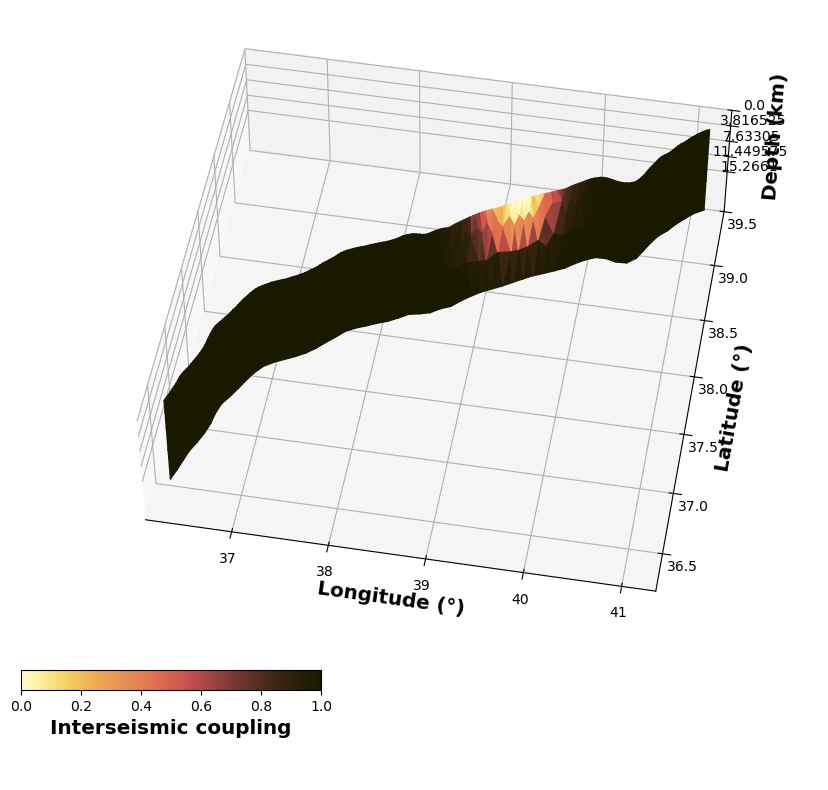

In [30]:
# A little cooking to define a creep zone :)

# Get patch centers
patch_centers = np.array(fault_EAF.getcenters(coordinates='ll'))
patch_lon, patch_lat, patch_z = patch_centers[:, 0], patch_centers[:, 1], patch_centers[:, 2]

# Compute distance along fault for each patch
patch_dalong = np.array([fault_EAF.distance2trace(lon=lon, lat=lat, coord='ll')[0] for lon, lat in zip(patch_lon, patch_lat)])

# Get long term slip rate along the fault predicted by the block model
turkey_multiblocks.GetLongTermSlipRate()

# Creep with a gaussian distribution along strike and with depth
f = scistats.multivariate_normal(mean=[200, 0.], cov=[[700, 0], [0, 50]])
coupling = f.pdf(np.vstack((patch_dalong, patch_z)).T)
coupling = 1 - coupling / np.max(coupling)
fault_EAF.coupling = coupling
fault_EAF.slip = np.tile(coupling, (3, 1)).T * fault_EAF.longterm_slip

# Show the coupling and the slip distribution along the fault
fault_EAF.plot(slip='coupling', cmap=cmc.lajolla_r, cblabel='Interseismic coupling', norm=(0, 1), figsize=((10, 10), None),
               view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4], Map=False, cbaxis=[0.1, 0.2, 0.3, 0.02])
# fault_EAF.plot(slip='strikeslip', cmap=cmc.acton_r, cblabel='Strike slip (mm/yr)', norm=(0, 10), figsize=((10, 10), None),
#                view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4], Map=False, cbaxis=[0.1, 0.2, 0.3, 0.02])
# fault_EAF.plot(slip='tensileslip', cmap=cmc.acton_r, cblabel='Tensile slip (mm/yr)', norm=(0, 10), figsize=((10, 10), None),
#                view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4], Map=False, cbaxis=[0.1, 0.2, 0.3, 0.02])

We compute the predictions and compare them with the GNSS velocity field.

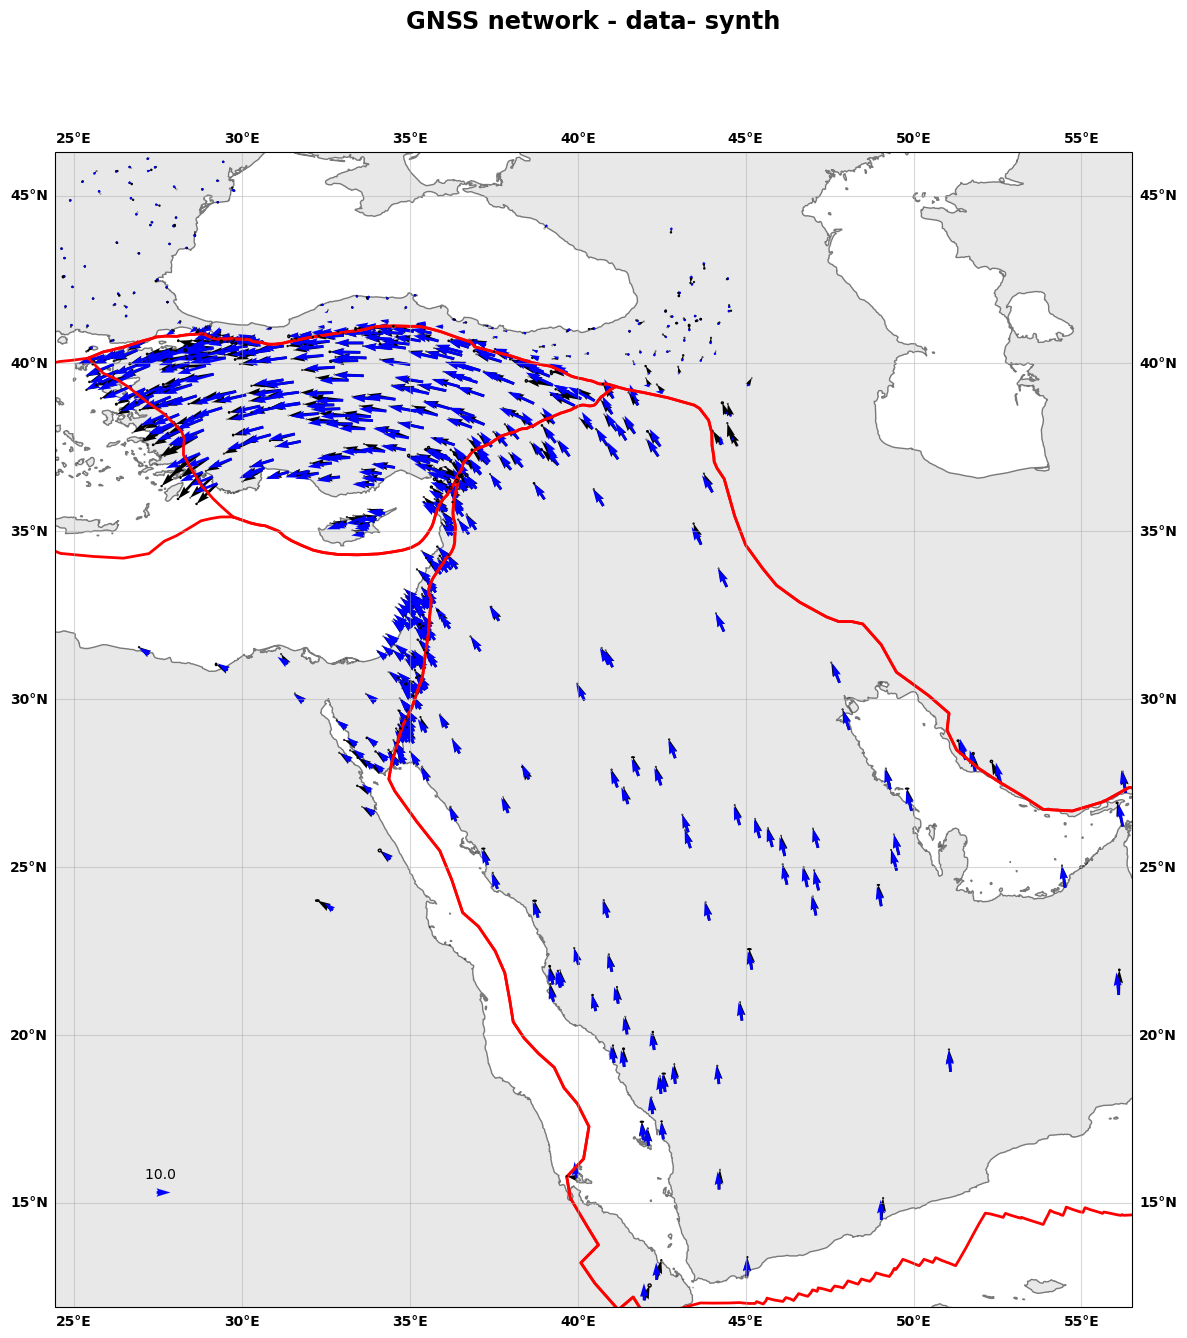

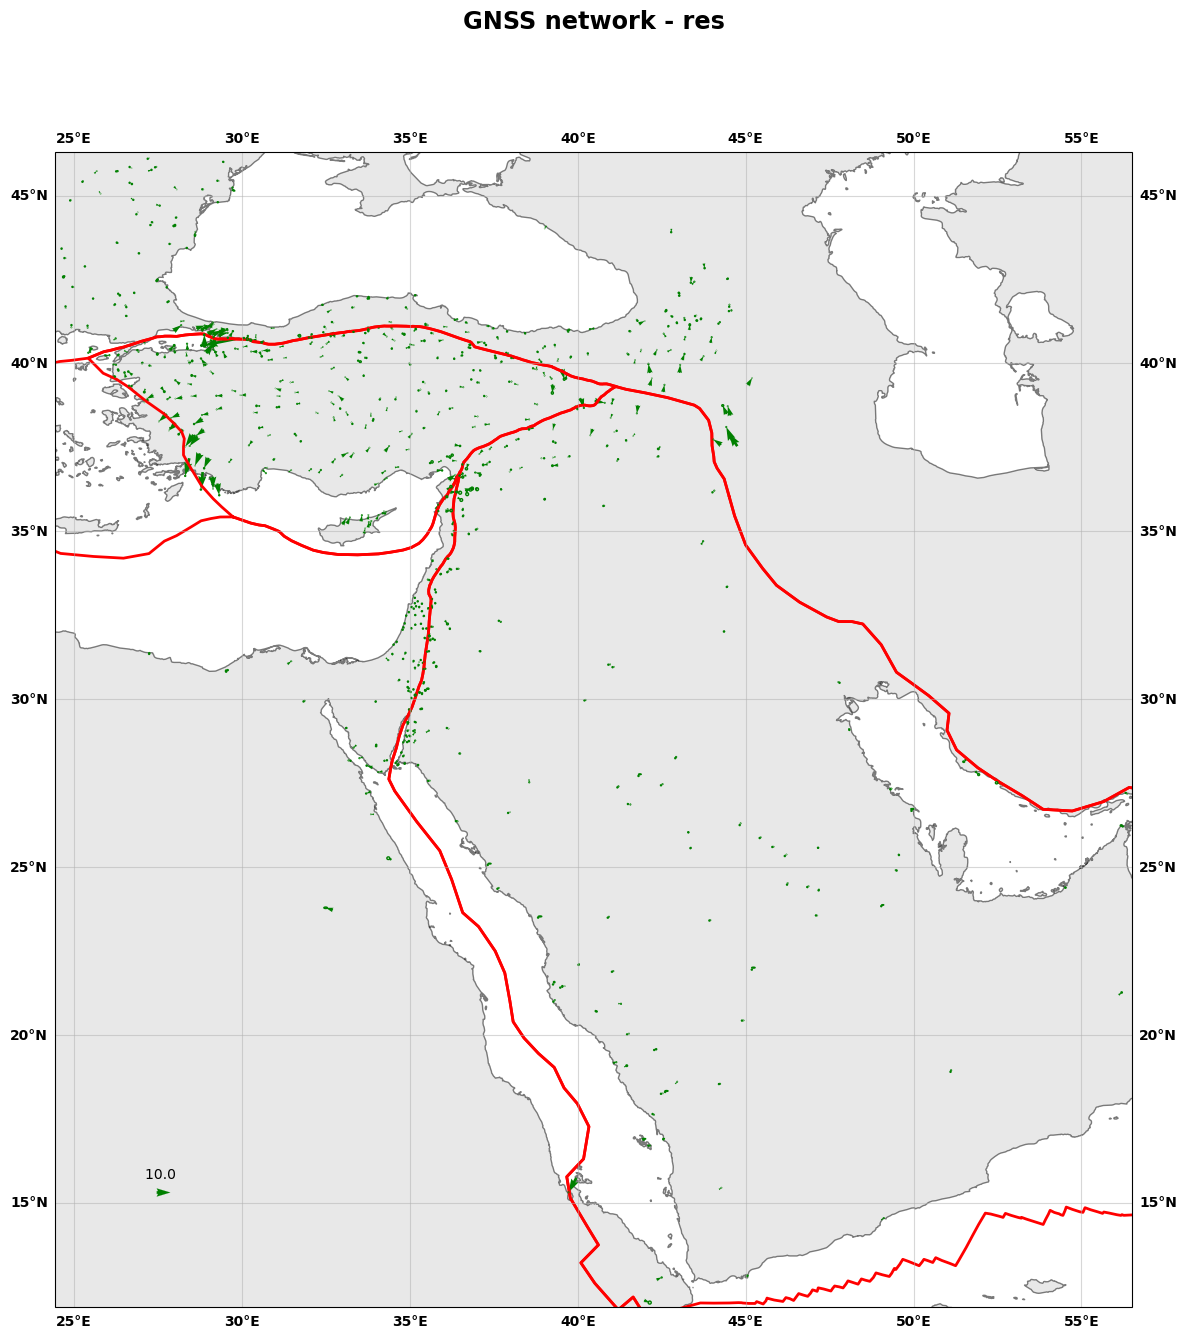

In [31]:
for gnss in GNSSs:
    
    # We build the synthetic data for the GNSS stations
    gnss.buildsynth([turkey_multiblocks, fault_EAF], blockcomponent='rotation+boundary', direction='st')
    
    # We show the GNSS data, the synthetic data and the residuals
    gnss.plot(data=['data', 'synth'], color=['k', 'b'], figsize=(15, 15), scale=25., blocks=Blocks, width=0.0025)
    gnss.plot(data=['res'], color=['g'], figsize=(15,15), scale=25., blocks=Blocks, width=0.0025)

It's hard to make out anything in the GNSS data; it would be easier to see in the InSAR data.

## Inversion

Now that we've played around with the parameters involved, we'll try to provide an estimate based on the geodetic data. This is where the action is. We will make an attempt with a generalized least-squares solution. 

### Assemble the data, data covariance and Green's functions

Different elements must be assembled together to enter in the inversion. Assembling means concatenating the various data vectors and GFs and covariance matrices before actually inverting the problem.

In [32]:
# Assemble the Green's Functions, data and data covariance matrices for the transformation between data
GeomTransformation.assembleGFs(Datas)
GeomTransformation.assembled(Datas)
GeomTransformation.assembleCd(Datas)

# Assemble the Green's Functions, data and data covariance matrices for the block model object
# Here, the GNSS data is referenced to the Eurasia block so we do not consider the rotation of this block
# In a simpler where you invert for the rotation of all blocks, you can use simply blockcomponent='rotation+boundary'
# Here, we don't invert for intrablock strain.
turkey_multiblocks.assembleGFs(Datas,
                               blockcomponent={block_arabia.name: 'rotation+boundary',
                                               block_eurasia.name: '',
                                               block_africa.name: 'rotation+boundary',
                                               block_anatolia.name: 'rotation+boundary'})
turkey_multiblocks.assembled(Datas)
turkey_multiblocks.assembleCd(Datas)

# Assemble the Green's Functions, data and data covariance matrices for the East Anatolian Fault
# Here, I only use the strike slip component and discard the dipslip
fault_EAF.assembleGFs(Datas, slipdir='s')
fault_EAF.assembled(Datas)
fault_EAF.assembleCd(Datas)

---------------------------------
---------------------------------
Assembling G for transformation Reference frame Corrections
Dealing with GNSS network of type gps
Dealing with InSAR TUR-A043 of type insar
Dealing with InSAR TUR-A116 of type insar
Dealing with InSAR TUR-D021 of type insar
Dealing with InSAR TUR-D123 of type insar
---------------------------------
---------------------------------
Assembling d for transformation Reference frame Corrections
Dealing with data GNSS network of type gps
Dealing with data InSAR TUR-A043 of type insar
Dealing with data InSAR TUR-A116 of type insar
Dealing with data InSAR TUR-D021 of type insar
Dealing with data InSAR TUR-D123 of type insar
---------------------------------
---------------------------------
Assembling Cd for transformation Reference frame Corrections
Dealing with data GNSS network of type gps
Dealing with data InSAR TUR-A043 of type insar
Dealing with data InSAR TUR-A116 of type insar
Dealing with data InSAR TUR-D021 of type 

### Regularization

In CSI, there is no fancy regularization scheme. I do not use any regularization when using AlTar, the Bayesian sampler. If you feel like implementing new ones, be my guest! Here, for the fault slip parameters, we use the approach of [Radiguet et al., 2010](https://doi.org/10.1111/j.1365-246X.2010.04866.x) (exponential decay of the model covariance as a function of the distance between patches). For the block rotation vectors and the transformation parameters, we use diagonal model covariance matrices.

In [33]:
# MultiBlocks
turkey_multiblocks.buildCmGaussian(sigma_rot=1e4)

# Faults
fault_EAF.buildCm(sigma=10, lam=5)

# Transformation
GeomTransformation.buildCm(sigma=10.)

---------------------------------
---------------------------------
Assembling the Cm matrix for multiblock Turkey Block Model
sigma rotation = 10000.0
sigma intradef = None
---------------------------------
---------------------------------
Assembling the Cm matrix for fault EAF
sigma = 10
lambda = 5
lambda0 = 0.8894263482247456
---------------------------------
---------------------------------
Assembling the Cm matrix for transformation Reference frame Corrections
sigma = 10.0


### Prepare the solver

In [34]:
# Initialize a csi solver object
slv = csi.multisourcesolve('inversion block model', [fault_EAF, turkey_multiblocks, GeomTransformation])

# Assemble Green's functions and data covariance for the solver
slv.assembleGFs()
slv.assembleCm()

---------------------------------
---------------------------------
Initializing solver object
Number of data: 11677
Number of parameters: 621
Parameter Description ----------------------------------
-----------------
Fault Name                    ||Strike Slip ||Dip Slip    ||Tensile Slip||Coupling    ||Extra Parms 
EAF                           ||   0 -  600 ||None        ||None        ||None        ||None        
-----------------
Block Name                    ||Rotation    ||Intra def.  ||Extra Parms 
Arabia                        || 600 -  603 ||None        ||None        
-----------------
Block Name                    ||Rotation    ||Intra def.  ||Extra Parms 
Eurasia                       ||None        ||None        ||None        
-----------------
Block Name                    ||Rotation    ||Intra def.  ||Extra Parms 
Nubia                         || 603 -  606 ||None        ||None        
-----------------
Block Name                    ||Rotation    ||Intra def.  ||Extra Parm

### Problem solving

Here, we solve the Generalized least squares problem without any other constraints than those implemented in the data and model covariances. The solution is the maximum of the posterior PDF which is a Gaussian distribution assuming Gaussian priors and likelihood.

In [35]:
# Solve
slv.GeneralizedLeastSquareSoln()

# Distribute results in the different objects (faults, blocks, transformation)
slv.distributem()

# Get longterm slip rates along faults and coupling
turkey_multiblocks.GetCoupling()

---------------------------------
---------------------------------
Computing the Generalized Inverse
Computing the inverse of the model covariance
Computing the inverse of the data covariance
Computing m_post


### Results

It's interesting to look at the long-term slip rates predicted by the block model for faults.

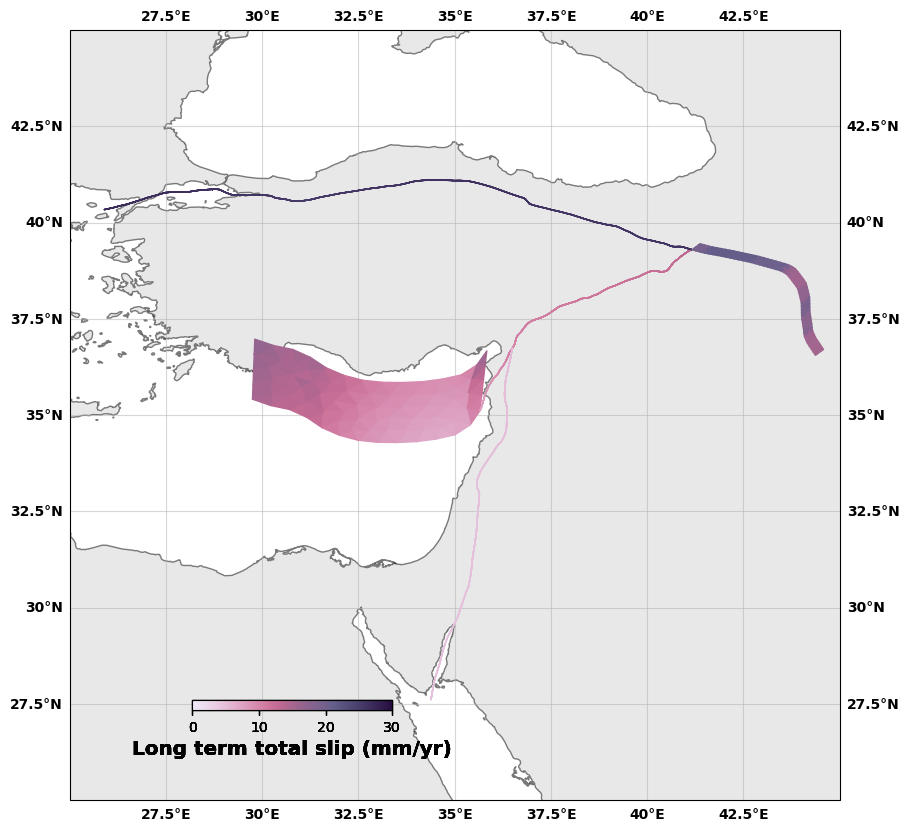

In [36]:
# We compute the long-term slip rate on the faults from the block rotations
turkey_multiblocks.GetLongTermSlipRate()

# We show the different components of the slip

# strike slip
# turkey_multiblocks.plot(slip='longtermstrikeslip', cmap=cmc.vik, cblabel='Long term strike slip (mm/yr)', norm=(-30, 30),
#                         view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4],
#                         box=[25, 45, 25, 45], figsize=((10, 10), (10, 10)), Fault=False, cbaxis=[.25, .2, 0.2, 0.01],
#                         plotBlockBoundaries2d=False)

# dip slip
# turkey_multiblocks.plot(slip='longtermdipslip', cmap=cmc.vik, cblabel='Long term dip slip (mm/yr)', norm=(-30, 30),
#                         view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4],
#                         box=[25, 45, 25, 45], figsize=((10, 10), (10, 10)), Fault=False, cbaxis=[.25, .2, 0.2, 0.01],
#                         plotBlockBoundaries2d=False)

# tensile slip
# turkey_multiblocks.plot(slip='longtermtensileslip', cmap=cmc.vik, cblabel='Long term tensile slip (mm/yr)', norm=(-30, 30),
#                         view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4],
#                         box=[25, 45, 25, 45], figsize=((10, 10), (10, 10)), Fault=False, cbaxis=[.25, .2, 0.2, 0.01],
#                         plotBlockBoundaries2d=False)

# total slip
turkey_multiblocks.plot(slip='longtermtotalslip', cmap=cmc.acton_r, cblabel='Long term total slip (mm/yr)', norm=(0, 30),
                        view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4],
                        box=[25, 45, 25, 45], figsize=((10, 10), (10, 10)), Fault=False, cbaxis=[.25, .2, 0.2, 0.01],
                        plotBlockBoundaries2d=False)

We can compute the coupling along the East Anatolian Fault.

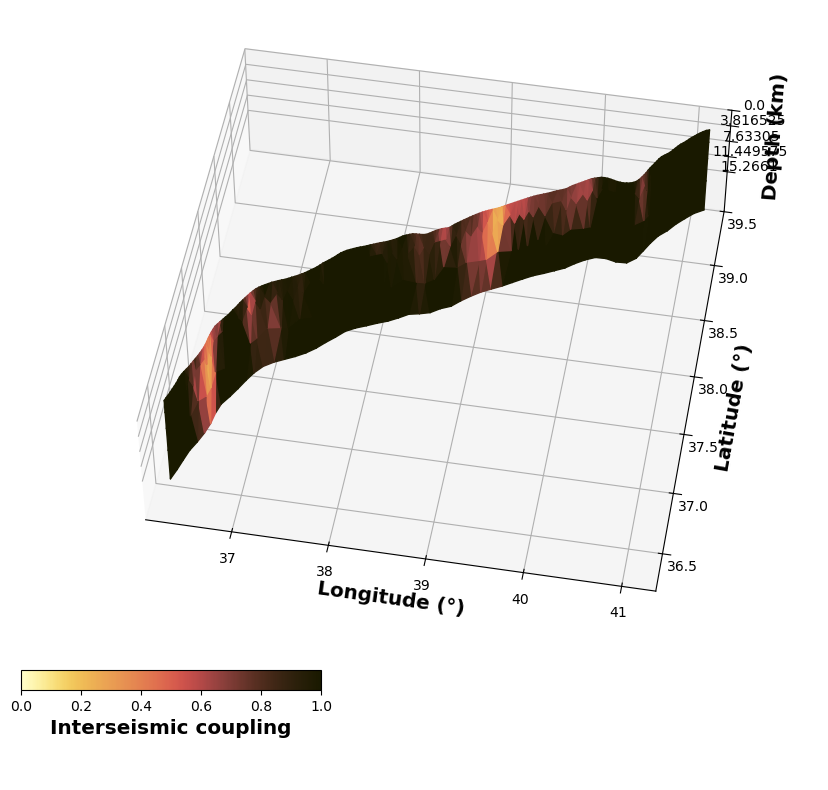

In [37]:
# We compute the long-term slip rate on the faults from the block rotations
turkey_multiblocks.GetCoupling()

# Show
fault_EAF.plot(slip='coupling', cmap=cmc.lajolla_r, cblabel='Interseismic coupling', norm=(0, 1), figsize=((10, 10), None),
               view={'elevation': 50., 'azimuth': 280.}, shape=[1., 1., 0.4], Map=False, cbaxis=[0.1, 0.2, 0.3, 0.02])

### Predictions

We can examine how well the predictions fit the data.

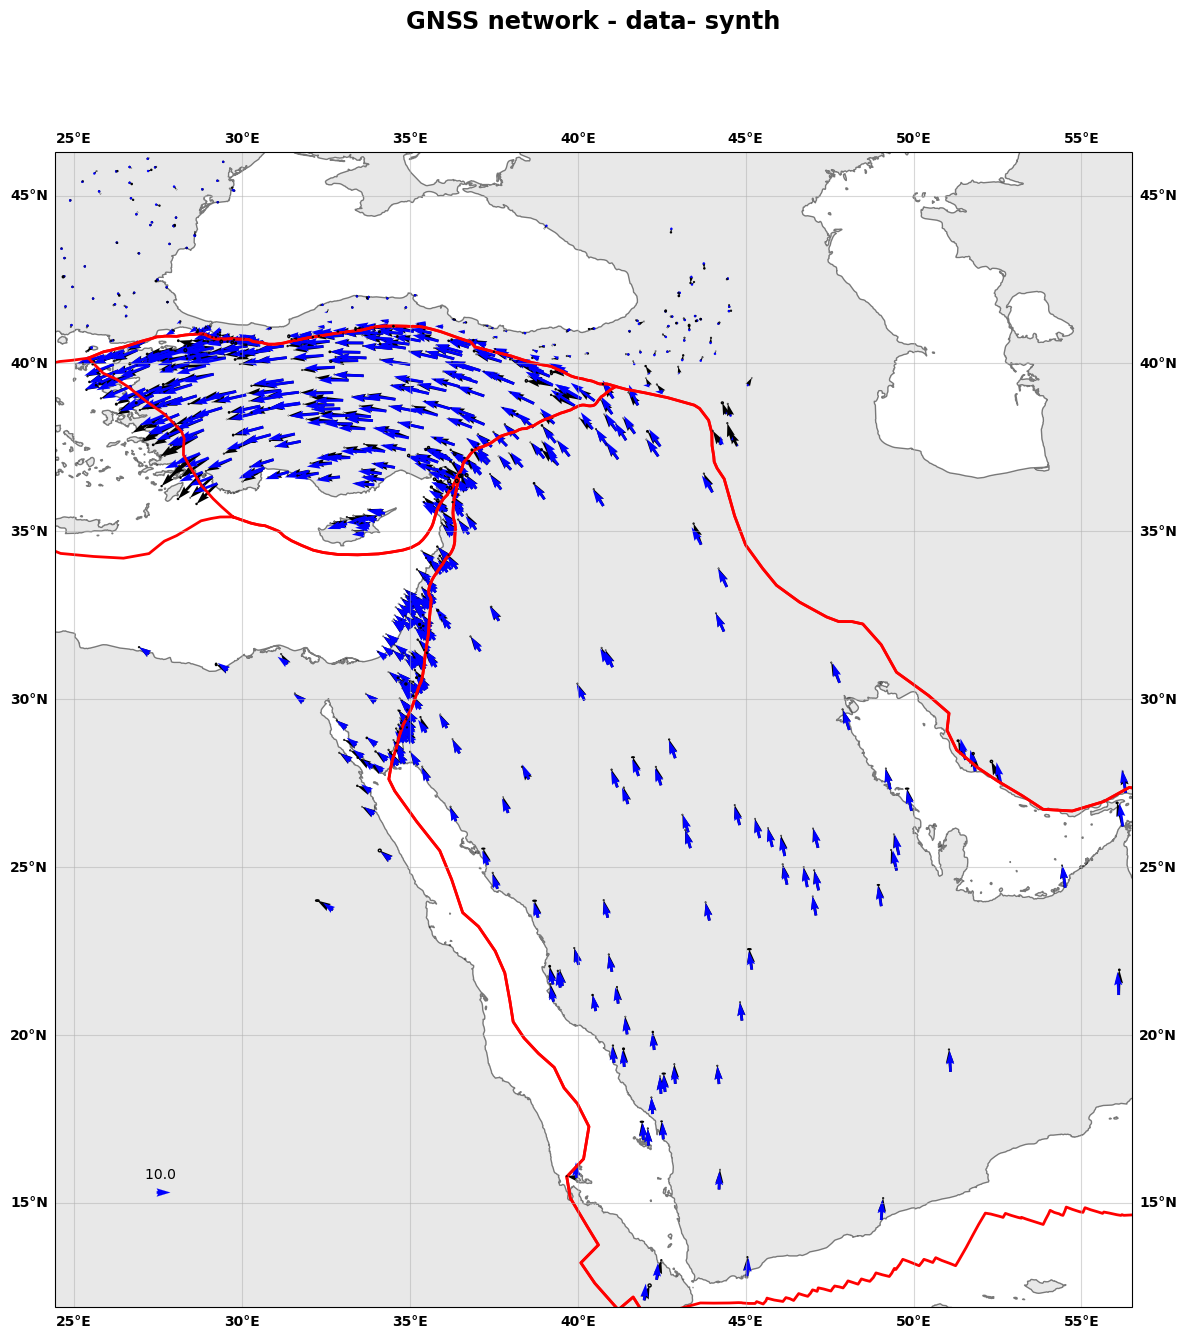

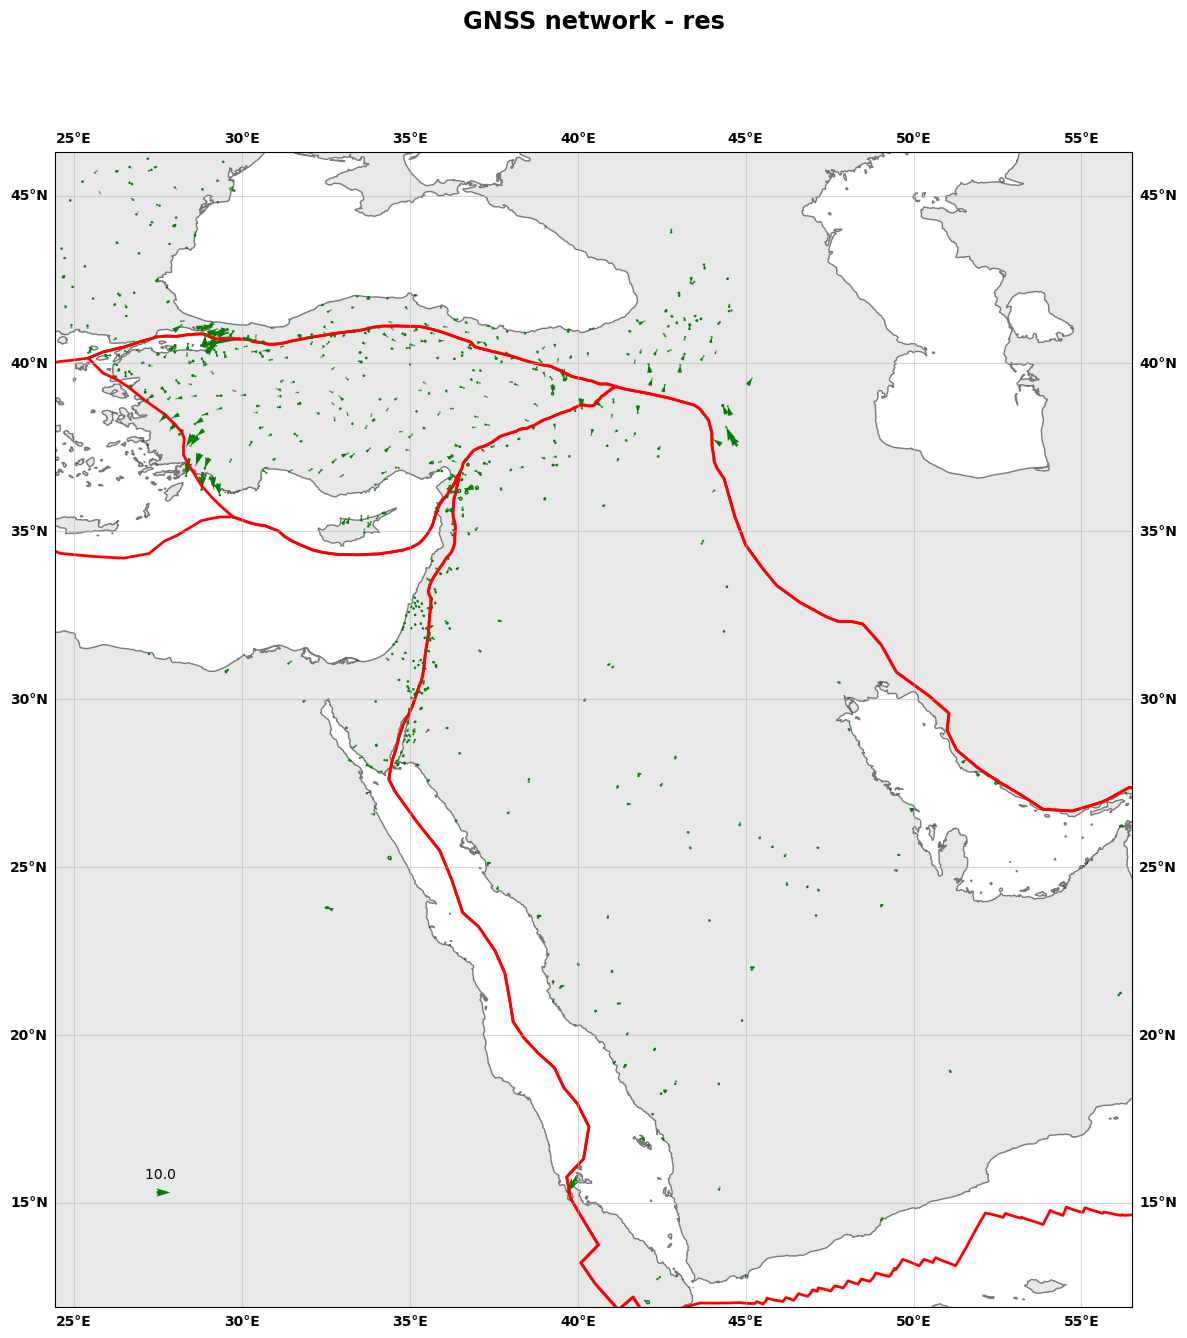

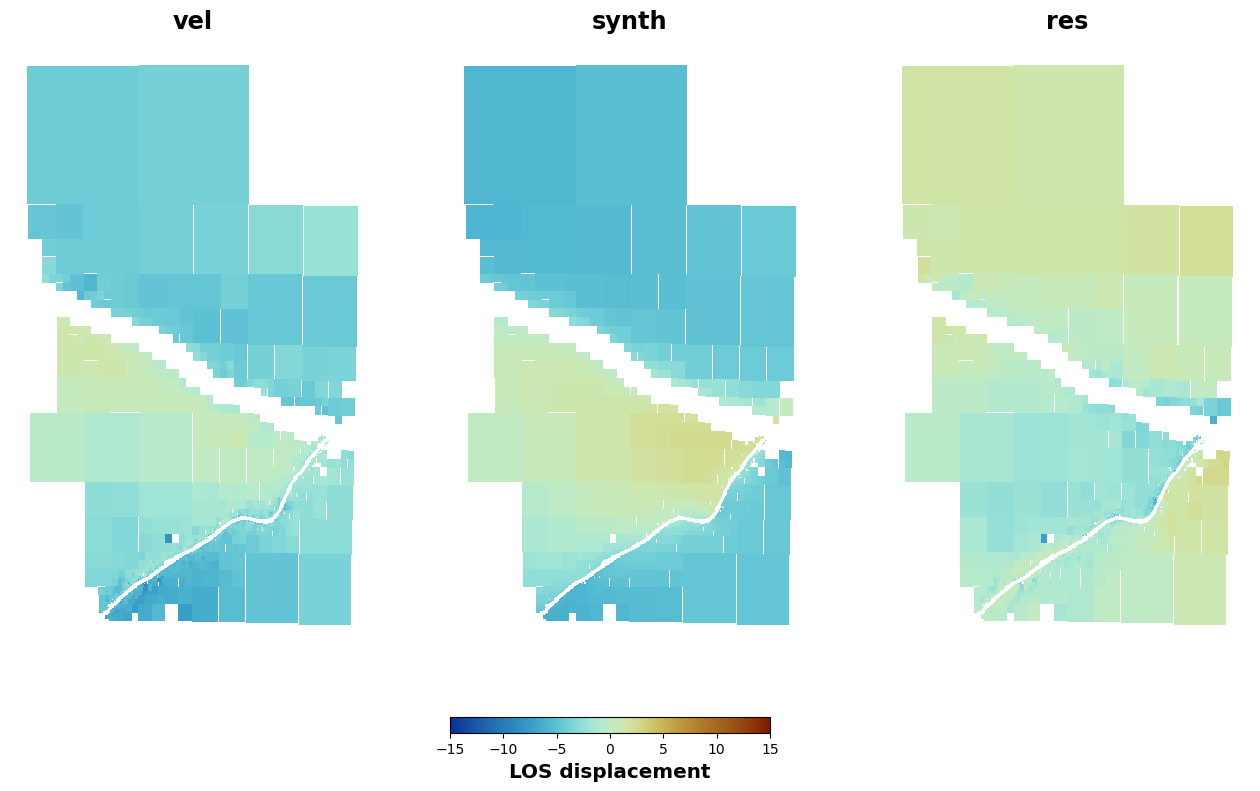

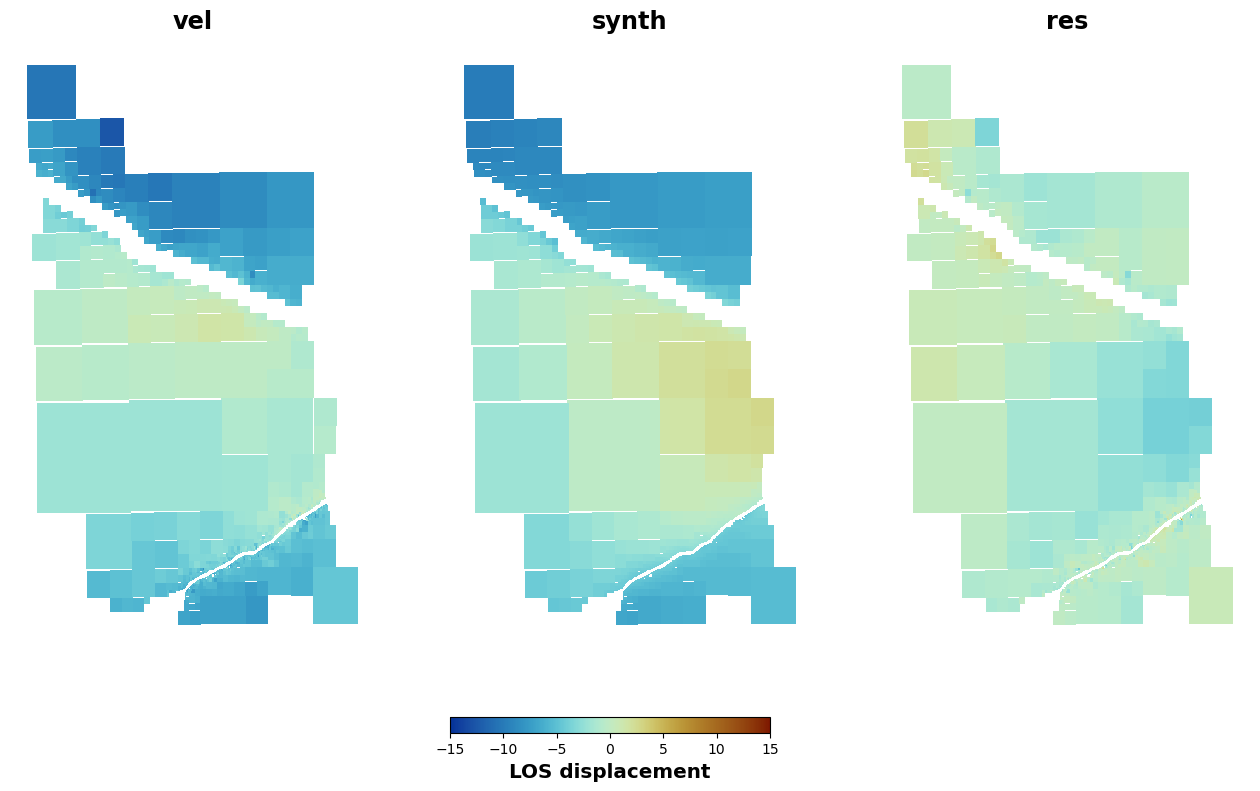

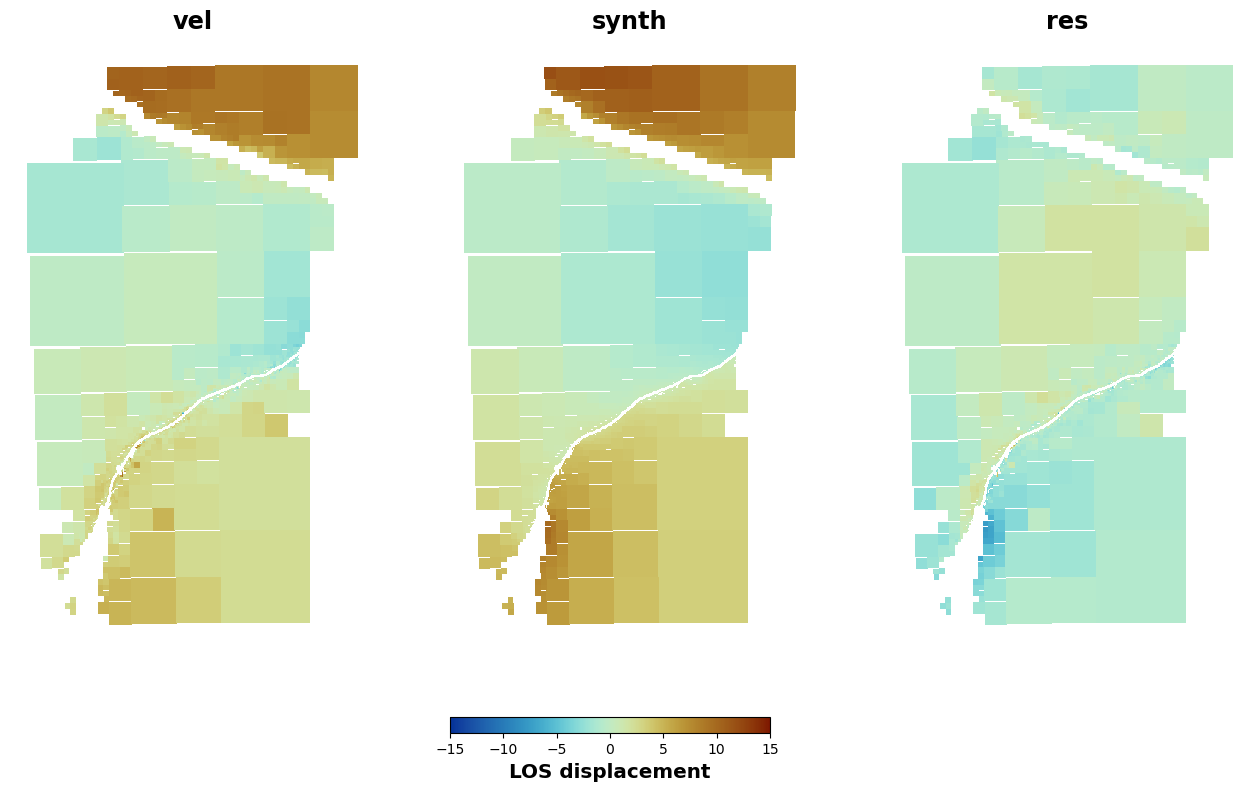

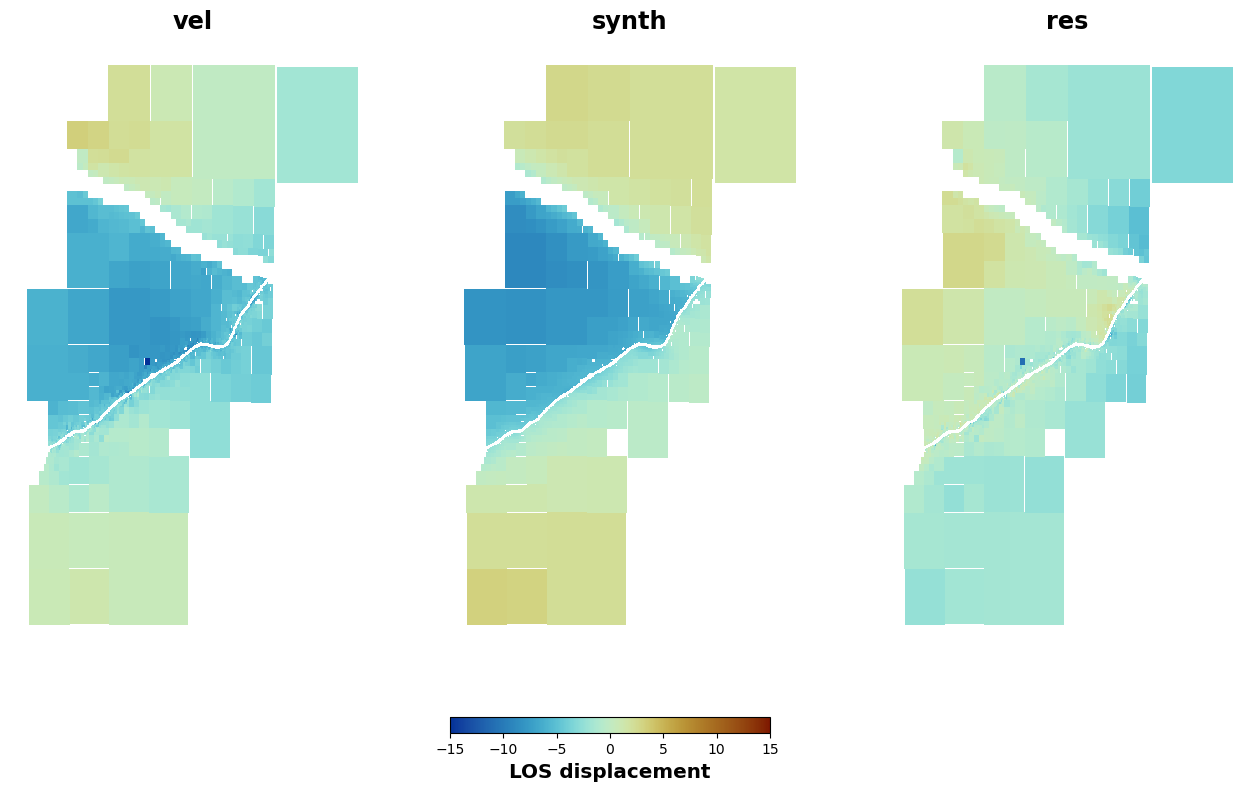

In [38]:
# GNSS data
for gnss in GNSSs:
    
    # Build the synthetic data for the GNSS stations
    gnss.buildsynth([GeomTransformation, fault_EAF, turkey_multiblocks], vertical=False,
                    blockcomponent=turkey_multiblocks.blockcomponent, direction='sdt')
    
    # Show the GNSS data, the synthetic data and the residuals
    gnss.plot(data=['data', 'synth'], color=['k', 'b'], figsize=(15,15), scale=25., blocks=Blocks, width=0.0025)
    gnss.plot(data=['res'], color=['g'], figsize=(15,15), scale=25., blocks=Blocks, width=0.0025)


# InSAR data
for sar in InSARs:
    
    # Build the synthetic data for the InSAR tracks
    sar.buildsynth([GeomTransformation, fault_EAF, turkey_multiblocks],
                   vertical=True, blockcomponent=turkey_multiblocks.blockcomponent, direction='sdt')
    
    # Show the InSAR data, the synthetic data and the residuals
    sar.plotDecimation(data=['vel', 'synth', 'res'], norm=[-15, 15], figsize=(16, 8), edgewidth=0.0,
                       cmap=cmc.roma_r)

That's it for now! Lots of tuning can be done, including better smoothing, better Green's functions, better internal strain estimation. You can also add some constraints, like imposing bottom patches of a fault to slip at the long-term slip rates. All of this is possible within CSI and the sky is the limit since you can implement what you want in CSI!